# 📊 Statistical Analysis — MyAnimeList Dataset
## Data Analysis Lab — Part I

**Domain:** Entertainment / Anime  
**Source:** [MyAnimeList](https://myanimelist.net/) (MAL) — via Kaggle  
**Objective:** Exploratory and statistical analysis of the MyAnimeList dataset, including detailed dataset description, statistical measures, feature engineering, visualization, and critical analysis.

---

## 📌 Table of Contents

1. [Dataset Description](#1-dataset-description)
   - [1.1 Overview](#11-overview)
   - [1.2 File Overview](#12-file-overview-automatic)
   - [1.3 Data Loading](#13-data-loading)
   - [1.4 Structure and Data Types](#14-structure-and-data-types)
   - [1.5 Data Cleaning and Preparation](#15-data-cleaning-and-preparation)
2. [Statistical Analysis](#2-statistical-analysis)
   - [2.1 Descriptive Statistics — Anime](#21-descriptive-statistics-anime-detailscsv)
   - [2.2 Descriptive Statistics — User Ratings](#22-descriptive-statistics-user-ratings)
   - [2.3 Descriptive Statistics — User Profiles](#23-descriptive-statistics-user-profiles)
   - [2.4 Covariance Analysis](#24-covariance-analysis)
   - [2.5 Correlation Analysis (Pearson)](#25-correlation-analysis-pearson)
   - [2.6 Statistical Analysis by Anime Type](#26-statistical-analysis-by-anime-type)
   - [2.7 Covariance & Correlation — Viewing Statistics](#27-covariance-and-correlation-viewing-statistics-statscsv)
   - [2.8 Correlation — User Profiles](#28-correlation-user-profiles)
   - [2.9 Covariance — User Profiles](#29-covariance-user-profiles)
3. [Feature Engineering](#3-feature-engineering-creating-new-variables)
   - [3.1 Engagement Ratios](#31-engagement-ratios)
   - [3.2 Score Classifications and Tiers](#32-score-classifications-and-tiers)
   - [3.3 Temporal Features](#33-temporal-features)
   - [3.4 Hidden Gems, Mainstream Giants & Underrated](#34-hidden-gems-mainstream-giants-underrated)
   - [3.5 Studio and Source Material Features](#35-studio-and-source-material-features)
   - [3.6 Genre Features](#36-genre-features)
   - [3.7 Binge-ability Calculator](#37-binge-ability-calculator)
   - [3.8 Summary of Created Features](#38-summary-of-created-features)
   - [3.9 Additional Features](#39-additional-features)
4. [Graphical Analysis (EDA Visualizations)](#4-graphical-analysis)
   - [4.1 Distribution Analysis](#41-distributions)
   - [4.2 Category Analysis](#42-category-analysis)
   - [4.3 Variable Relationships](#43-variable-relationships)
   - [4.4 Temporal Analysis](#44-temporal-analysis)
   - [4.5 Visualizations of Engineered Features](#45-visualizations-of-created-features)
5. [Normalization and Standardization](#5-normalization-and-standardization)
6. [Critical Analysis](#6-critical-analysis)
   - [6.1 Data Quality](#61-data-quality)
   - [6.2 Dataset Biases and Limitations](#62-dataset-biases-and-limitations)
   - [6.3 Engineered Features Analysis](#63-created-features-distribution-analysis)
   - [6.4 Representativeness and Generalization](#64-representativeness-and-generalization)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = 'datasets'
print("Libraries imported successfully!")

Bibliotecas importadas com sucesso!


---
# 1. Dataset Description

## 1.1 Overview

The **MyAnimeList** dataset contains detailed information about anime, users, ratings, characters, and voice/production staff. The data was extracted from the website [MyAnimeList.net](https://myanimelist.net/), one of the largest online communities dedicated to anime and manga.

### Main Entities
- **Anime**: information about series, movies, OVAs (29K+ titles)
- **Users**: user profiles on the platform (337K+ profiles)
- **Ratings**: user ratings for anime (~4.3 GB file)
- **Characters**: information about anime characters (100K+)
- **Staff/Voice Actors**: people involved in production (77K+)

### Dataset Files
| File | Size | Records | Description |
|---|---|---|---|
| `details.csv` | 19.2 MB | 28,955 | Anime metadata (title, score, genre, studio, etc.) |
| `stats.csv` | 3.4 MB | 28,955 | Viewing statistics and score distribution |
| `ratings.csv` | 4.3 GB | ~109M | Individual user ratings |
| `profiles.csv` | 17.1 MB | 337,155 | User profiles |
| `recommendations.csv` | 1.1 MB | 105,249 | Recommendations between anime |
| `favs.csv` | 97.4 MB | ~3.5M | User favorites |
| `characters.csv` | 71.9 MB | ~280K | Character information |
| `character_anime_works.csv` | 7.9 MB | 236,816 | Character-anime relationship |
| `person_details.csv` | 16.3 MB | 76,699 | Staff/VA details |
| `person_anime_works.csv` | 17.8 MB | 458,091 | Staff works in anime |
| `person_voice_works.csv` | 16.6 MB | 489,516 | Voice acting works |
| `character_nicknames.csv` | 0.6 MB | 37,080 | Character nicknames |
| `person_alternate_names.csv` | 0.4 MB | 20,465 | Alternative staff names |

## 1.2 File Overview (Automatic)

In [2]:
# Display file information automatically
import csv

files_info = []
for f in sorted(os.listdir(DATA_PATH)):
    if f.endswith('.csv'):
        filepath = os.path.join(DATA_PATH, f)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        with open(filepath, encoding='utf-8', errors='replace') as fh:
            reader = csv.reader(fh)
            headers = next(reader)
        files_info.append({'File': f, 'Size (MB)': round(size_mb, 1), 'Colunas': len(headers), 'Nomes das Colunas': ', '.join(headers[:6]) + ('...' if len(headers) > 6 else '')})

files_df = pd.DataFrame(files_info)
files_df

,Ficheiro,Tamanho (MB),Colunas,Nomes das Colunas
0,anime_enriched.csv,22.20,84,"mal_id, title, title_japanese, url, image_url,..."
1,character_anime_works.csv,7.90,4,"anime_mal_id, character_mal_id, character_name..."
2,character_nicknames.csv,0.60,2,"character_mal_id, nickname"
3,characters.csv,71.90,7,"character_mal_id, url, name, name_kanji, image..."
4,details.csv,19.20,29,"mal_id, title, title_japanese, url, image_url,..."
5,favs.csv,97.40,3,"username, fav_type, id"
6,person_alternate_names.csv,0.40,2,"person_mal_id, alt_name"
7,person_anime_works.csv,17.80,3,"person_mal_id, position, anime_mal_id"
8,person_details.csv,16.30,10,"person_mal_id, url, website_url, image_url, na..."
9,person_voice_works.csv,16.60,5,"person_mal_id, role, anime_mal_id, character_m..."


## 1.3 Data Loading

Let's load the main files for analysis. The `ratings.csv` file (~4.3 GB) will be sampled due to its size.

In [3]:
# Load main files
details = pd.read_csv(os.path.join(DATA_PATH, 'details.csv'))
stats = pd.read_csv(os.path.join(DATA_PATH, 'stats.csv'))
profiles = pd.read_csv(os.path.join(DATA_PATH, 'profiles.csv'))
recommendations = pd.read_csv(os.path.join(DATA_PATH, 'recommendations.csv'))

print(f"details.csv: {details.shape[0]:,} rows × {details.shape[1]} columns")
print(f"stats.csv: {stats.shape[0]:,} rows × {stats.shape[1]} columns")
print(f"profiles.csv: {profiles.shape[0]:,} rows × {profiles.shape[1]} columns")
print(f"recommendations.csv: {recommendations.shape[0]:,} rows × {recommendations.shape[1]} columns")

details.csv: 28,955 linhas × 29 colunas
stats.csv: 28,955 linhas × 27 colunas
profiles.csv: 337,155 linhas × 10 colunas
recommendations.csv: 105,249 linhas × 2 colunas


In [4]:
# Sample the ratings.csv file using chunk reading
# (more efficient than skiprows for large files)
ratings_chunks = []
chunk_size = 500_000
sample_frac = 0.005  # ~0.5% of the file

for chunk in pd.read_csv(os.path.join(DATA_PATH, 'ratings.csv'), chunksize=chunk_size):
    sampled = chunk.sample(frac=sample_frac, random_state=42)
    ratings_chunks.append(sampled)

ratings = pd.concat(ratings_chunks, ignore_index=True)
print(f"ratings.csv: sample of {ratings.shape[0]:,} rows × {ratings.shape[1]} columns")

ratings.csv: amostra de 621,492 linhas × 6 colunas


## 1.4 Structure and Data Types

### `details.csv` Table — Anime Metadata
This is the main table, containing detailed information for each anime.

In [5]:
print("=== DETAILS.CSV — Data Types ===\n")
print(details.dtypes)
print(f"\nMemory used: {details.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

=== DETAILS.CSV — Tipos de Dados ===

mal_id               int64
title               object
title_japanese      object
url                 object
image_url           object
type                object
status              object
score              float64
scored_by          float64
start_date          object
end_date            object
synopsis            object
rank               float64
popularity           int64
members              int64
favorites            int64
genres              object
studios             object
themes              object
demographics        object
source              object
rating              object
episodes           float64
season              object
year               float64
producers           object
explicit_genres     object
licensors           object
streaming           object
dtype: object

Memória utilizada: 48.8 MB


In [6]:
details.head(10)

,mal_id,title,title_japanese,url,image_url,type,status,score,scored_by,start_date,end_date,synopsis,rank,popularity,members,favorites,genres,studios,themes,demographics,source,rating,episodes,season,year,producers,explicit_genres,licensors,streaming
0,59356,-Socket-,-socket-,https://myanimelist.net/anime/59356/-Socket-,https://cdn.myanimelist.net/images/anime/1043/...,Movie,Finished Airing,NaN,NaN,2010-01-01T00:00:00+00:00,NaN,A girl with a cord growing out of her back wan...,17086.00,22507,195,0,['Comedy'],[],[],[],Original,G - All Ages,1.00,NaN,NaN,['Nagoya Zokei University'],[],[],[]
1,56036,......,......,https://myanimelist.net/anime/56036/-,https://cdn.myanimelist.net/images/anime/1057/...,Music,Finished Airing,6.53,503.00,2023-06-11T00:00:00+00:00,NaN,Music video directed by obmolot for the song ....,NaN,15004,941,2,"['Horror', 'Supernatural']",['Flat Studio'],['Music'],[],Original,PG-13 - Teens 13 or older,1.00,NaN,NaN,[],[],[],[]
2,2928,.hack//G.U. Returner,.HACK//G.U. RETURNER,https://myanimelist.net/anime/2928/hack__GU_Re...,https://cdn.myanimelist.net/images/anime/1798/...,OVA,Finished Airing,6.65,9745.00,2007-01-18T00:00:00+00:00,NaN,The characters from previous .hack//G.U. Games...,6366.00,5056,22525,31,"['Adventure', 'Drama', 'Fantasy']",['Bee Train'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,"['Bandai Visual', 'CyberConnect2']",[],[],[]
3,3269,.hack//G.U. Trilogy,.hack//G.U. Trilogy,https://myanimelist.net/anime/3269/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/1566/...,Movie,Finished Airing,7.06,15373.00,2007-12-22T00:00:00+00:00,NaN,"Based on the CyberConnect2 HIT GAME, now will ...",4194.00,4215,34264,104,"['Action', 'Fantasy']",['CyberConnect2'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,['Bandai Visual'],[],"['Funimation', 'Bandai Entertainment']",[]
4,4469,.hack//G.U. Trilogy: Parody Mode,.hack//G.U. Trilogy,https://myanimelist.net/anime/4469/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/10/86...,Special,Finished Airing,6.35,4317.00,2008-03-25T00:00:00+00:00,NaN,A special bonus Parody Mode added to the extra...,8182.00,6696,11135,10,"['Comedy', 'Fantasy', 'Sci-Fi']",[],"['Parody', 'Video Game']",[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,['Bandai Visual'],[],[],[]
5,454,.hack//Gift,.hack//GIFT,https://myanimelist.net/anime/454/hack__Gift,https://cdn.myanimelist.net/images/anime/2/230...,OVA,Finished Airing,6.09,10021.00,2003-11-16T00:00:00+00:00,NaN,As an expression of gratitude for the heroes o...,9692.00,5162,21458,20,"['Comedy', 'Fantasy']",['Bee Train'],['Video Game'],[],Original,R+ - Mild Nudity,1.00,NaN,NaN,['CyberConnect2'],[],['Bandai Entertainment'],[]
6,1143,.hack//Intermezzo,.hack//Intermezzo,https://myanimelist.net/anime/1143/hack__Inter...,https://cdn.myanimelist.net/images/anime/1844/...,Special,Finished Airing,6.51,11616.00,2003-03-28T00:00:00+00:00,NaN,A virtual multiplayer online role-playing game...,7195.00,4910,24340,7,"['Adventure', 'Fantasy', 'Mystery', 'Sci-Fi']",['Bee Train'],['Video Game'],[],Original,PG-13 - Teens 13 or older,1.00,NaN,NaN,[],[],['Bandai Entertainment'],['Crunchyroll']
7,299,.hack//Liminality,.hack//LIMINALITY,https://myanimelist.net/anime/299/hack__Limina...,https://cdn.myanimelist.net/images/anime/7/230...,OVA,Finished Airing,6.58,17130.00,2002-06-20T00:00:00+00:00,2003-04-10T00:00:00+00:00,"While playing the newly released MMORPG ""The W...",6740.00,4178,34986,35,['Mystery'],['Bee Train'],['Video Game'],[],Original,PG-13 - Teens 13 or older,4.00,NaN,NaN,"['Bandai Visual', 'Bandai', 'CyberConnect2']",[],['Bandai Entertainment'],[]
8,9332,.hack//Quantum,.hack//Quantum,https://myanimelist.net/anime/9332/hack__Quantum,https://cdn.myanimelist.net/images/anime/1894/...,OVA,Finished Airing,7.11,20412.00,2011-01-28T00:00:00+00:00,2011-04-07T00:00:00+00:00,"Tobias, Mary, and Sakuya challenge the impregn...",3960.00,3808,42217,72,"['Action', 'Adventure', 'Fantasy']",['Kinema Citrus'],['Video Game'],[],Original

In [7]:
print("=== Null Values in details.csv ===\n")
null_counts = details.isnull().sum()
null_pct = (details.isnull().sum() / len(details) * 100).round(2)
null_df = pd.DataFrame({'Nulls': null_counts, 'Percentage (%)': null_pct})
null_df = null_df[null_df['Nulls'] > 0].sort_values('Percentage (%)', ascending=False)
print(null_df)
print(f"\nTotal columns with null values: {(null_counts > 0).sum()} de {len(details.columns)}")

=== Valores Nulos em details.csv ===

                Nulos  Percentagem (%)
year            22689            78.36
season          22689            78.36
end_date        17688            61.09
scored_by       10073            34.79
score           10073            34.79
rank             6958            24.03
synopsis         5127            17.71
start_date        851             2.94
episodes          680             2.35
rating            600             2.07
title_japanese    119             0.41
type               67             0.23

Total de colunas com valores nulos: 12 de 29


### `stats.csv` Table — Viewing Statistics
Contains aggregated data on the number of users watching, completed, on hold, or dropped for each anime, as well as the distribution of votes by score (1-10).

In [8]:
print("=== STATS.CSV — Data Types ===\n")
print(stats.dtypes)
print(f"\nMemory used: {stats.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

=== STATS.CSV — Tipos de Dados ===

mal_id                   int64
watching                 int64
completed                int64
on_hold                  int64
dropped                  int64
plan_to_watch            int64
total                    int64
score_1_votes          float64
score_1_percentage     float64
score_2_votes          float64
score_2_percentage     float64
score_3_votes          float64
score_3_percentage     float64
score_4_votes          float64
score_4_percentage     float64
score_5_votes          float64
score_5_percentage     float64
score_6_votes          float64
score_6_percentage     float64
score_7_votes          float64
score_7_percentage     float64
score_8_votes          float64
score_8_percentage     float64
score_9_votes          float64
score_9_percentage     float64
score_10_votes         float64
score_10_percentage    float64
dtype: object

Memória utilizada: 6.0 MB


In [9]:
stats.head(10)

,mal_id,watching,completed,on_hold,dropped,plan_to_watch,total,score_1_votes,score_1_percentage,score_2_votes,score_2_percentage,score_3_votes,score_3_percentage,score_4_votes,score_4_percentage,score_5_votes,score_5_percentage,score_6_votes,score_6_percentage,score_7_votes,score_7_percentage,score_8_votes,score_8_percentage,score_9_votes,score_9_percentage,score_10_votes,score_10_percentage
0,59356,7,146,4,20,20,197,2.00,2.20,0.00,0.00,3.00,3.30,6.00,6.60,25.00,27.50,33.00,36.30,19.00,20.90,2.00,2.20,0.00,0.00,1.00,1.10
1,56036,21,770,8,29,113,941,5.00,1.00,6.00,1.20,8.00,1.60,14.00,2.80,50.00,9.90,138.00,27.40,144.00,28.60,81.00,16.10,17.00,3.40,40.00,8.00
2,2928,451,14953,302,349,6472,22527,101.00,1.00,93.00,1.00,164.00,1.70,457.00,4.70,1184.00,12.10,2054.00,21.10,2709.00,27.80,1500.00,15.40,875.00,9.00,608.00,6.20
3,3269,726,22790,452,537,9762,34267,120.00,0.80,156.00,1.00,260.00,1.70,560.00,3.60,1270.00,8.30,2457.00,16.00,4157.00,27.00,3075.00,20.00,1919.00,12.50,1400.00,9.10
4,4469,241,6918,182,266,3528,11135,83.00,1.90,104.00,2.40,182.00,4.20,292.00,6.80,683.00,15.80,888.00,20.60,871.00,20.20,592.00,13.70,308.00,7.10,315.00,7.30
5,454,325,15421,261,423,5027,21457,265.00,2.60,312.00,3.10,444.00,4.40,881.00,8.80,1662.00,16.60,2108.00,21.00,2008.00,20.00,1111.00,11.10,609.00,6.10,621.00,6.20
6,1143,360,17510,302,323,5847,24342,85.00,0.70,104.00,0.90,246.00,2.10,595.00,5.10,1718.00,14.80,2805.00,24.10,3274.00,28.20,1615.00,13.90,655.00,5.60,519.00,4.50
7,299,858,24478,1149,998,7504,34987,114.00,0.70,148.00,0.90,291.00,1.70,833.00,4.90,2375.00,13.90,3877.00,22.60,4696.00,27.40,2635.00,15.40,1229.00,7.20,932.00,5.40
8,9332,1156,28997,635,683,10752,42223,125.00,0.60,65.00,0.30,185.00,0.90,522.00,2.60,1646.00,8.10,3378.00,16.50,6199.00,30.40,4781.00,23.40,2025.00,9.90,1487.00,7.30
9,10390,247,4643,166,293,3487,8836,66.00,2.30,51.00,1.80,68.00,2.40,162.00,5.80,391.00,13.90,569.00,20.20,567.00,20.20,431.00,15.30,336.00,12.00,169.00,6.00


### `profiles.csv` Table — User Profiles
Demographic information and activity statistics of platform users.

In [10]:
print("=== PROFILES.CSV — Data Types ===\n")
print(profiles.dtypes)
print(f"\nMemory used: {profiles.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

print("\n=== Null Values ===\n")
null_counts_p = profiles.isnull().sum()
null_pct_p = (profiles.isnull().sum() / len(profiles) * 100).round(2)
null_df_p = pd.DataFrame({'Nulls': null_counts_p, 'Percentage (%)': null_pct_p})
print(null_df_p)

=== PROFILES.CSV — Tipos de Dados ===

username         object
gender           object
birthday         object
location         object
joined           object
watching         object
completed        object
on_hold          object
dropped          object
plan_to_watch    object
dtype: object



Memória utilizada: 160.4 MB

=== Valores Nulos ===

                Nulos  Percentagem (%)
username            1             0.00
gender         170876            50.68
birthday       215826            64.01
location       225189            66.79
joined           1676             0.50
watching         1678             0.50
completed        1678             0.50
on_hold          1678             0.50
dropped          1678             0.50
plan_to_watch    1678             0.50


In [11]:
profiles.head(10)

,username,gender,birthday,location,joined,watching,completed,on_hold,dropped,plan_to_watch
0,ishikawas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CKK2,NaN,NaN,NaN,"Dec 1, 2018",3,182,15,0,405
2,--------788,Female,NaN,Brazil Salto De Pirapora,"Oct 4, 2022",1,64,0,0,1
3,potatoaris,NaN,NaN,NaN,"Oct 2, 2018",5,1,0,0,4
4,Rinrintan,NaN,NaN,NaN,"May 12, 2019",20,311,40,16,34
5,Karincakes,NaN,NaN,Antarctica,"Jan 5, 2015",79,"2,899",22,17,508
6,Folktal3wtb,NaN,NaN,NaN,"Jan 3, 2021",40,254,0,8,351
7,Monarchivist,NaN,NaN,NaN,"Nov 16, 2024",1,21,0,2,2
8,Thom_dos,NaN,NaN,NaN,"Sep 2, 2021",7,366,0,2,36
9,arizkykun,Male,NaN,NaN,"Jan 16, 2016",3,711,44,51,53


### `ratings.csv` Table — User Ratings (Sample)
Contains individual user ratings for each anime. Due to its size (~4.3 GB), we work with a sample.

In [12]:
print("=== RATINGS.CSV (SAMPLE) — Data Types ===\n")
print(ratings.dtypes)
print(f"\nMemory used: {ratings.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

=== RATINGS.CSV (AMOSTRA) — Tipos de Dados ===

username                 object
anime_id                  int64
status                   object
score                     int64
is_rewatching           float64
num_watched_episodes      int64
dtype: object



Memória utilizada: 88.4 MB


In [13]:
ratings.head(10)

,username,anime_id,status,score,is_rewatching,num_watched_episodes
0,KarlVonAnime,49387,completed,9,0.00,24
1,issa_labshat,47778,completed,9,0.00,11
2,ThomasPlayCz,56038,plan_to_watch,0,0.00,0
3,--Moose--,40221,completed,0,0.00,13
4,itachi1706,40454,watching,0,0.00,0
5,ispri7,185,completed,0,0.00,26
6,CM_k2205,6,plan_to_watch,0,0.00,0
7,RiptideRush,1527,completed,6,0.00,1
8,ishiruchan,1726,plan_to_watch,0,0.00,0
9,Karo_cchi,33513,completed,7,0.00,1


## 1.5 Data Cleaning and Preparation

Before proceeding with the statistical analysis, we must clean the data:
- Convert numeric columns with incorrect types
- Handle missing values
- Filter invalid records

In [14]:
# Convert numeric columns in details
details['score'] = pd.to_numeric(details['score'], errors='coerce')
details['scored_by'] = pd.to_numeric(details['scored_by'], errors='coerce')
details['rank'] = pd.to_numeric(details['rank'], errors='coerce')
details['popularity'] = pd.to_numeric(details['popularity'], errors='coerce')
details['members'] = pd.to_numeric(details['members'], errors='coerce')
details['favorites'] = pd.to_numeric(details['favorites'], errors='coerce')
details['episodes'] = pd.to_numeric(details['episodes'], errors='coerce')
details['year'] = pd.to_numeric(details['year'], errors='coerce')

# Convert numeric columns in ratings
ratings['score'] = pd.to_numeric(ratings['score'], errors='coerce')
ratings['num_watched_episodes'] = pd.to_numeric(ratings['num_watched_episodes'], errors='coerce')

# Convert numeric columns in profiles
for col in ['watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch']:
    profiles[col] = pd.to_numeric(profiles[col], errors='coerce')

# Convert numeric columns in stats
numeric_cols_stats = stats.columns.drop('mal_id')
for col in numeric_cols_stats:
    stats[col] = pd.to_numeric(stats[col], errors='coerce')

print("Type conversion completed!")
print(f"\nDetails - valid scores: {details['score'].notna().sum():,} de {len(details):,}")
print(f"Ratings - valid scores: {ratings['score'].notna().sum():,} de {len(ratings):,}")

Conversão de tipos concluída!

Details - scores válidos: 18,882 de 28,955
Ratings - scores válidos: 621,492 de 621,492


In [15]:
# Create subset of anime with valid score for analysis
details_scored = details[details['score'].notna() & (details['score'] > 0)].copy()
print(f"Anime with valid score (>0): {len(details_scored):,} de {len(details):,} ({len(details_scored)/len(details)*100:.1f}%)")

# Create subset of ratings with valid score
ratings_scored = ratings[ratings['score'].notna() & (ratings['score'] > 0)].copy()
print(f"Ratings with valid score: {len(ratings_scored):,} de {len(ratings):,} ({len(ratings_scored)/len(ratings)*100:.1f}%)")

Animes com score válido (>0): 18,882 de 28,955 (65.2%)
Ratings com score válido: 348,062 de 621,492 (56.0%)



[⬆ Back to Index](#-table-of-contents)

---

---
# 2. Statistical Analysis

In this section we calculate the main statistical measures: **mean, median, variance, standard deviation, minimum, maximum, quartiles**, for the most relevant numerical variables.

## 2.1 Descriptive Statistics — Anime (details.csv)

In [16]:
# Select key numerical variables of anime
anime_numeric_cols = ['score', 'scored_by', 'members', 'favorites', 'episodes', 'year', 'rank', 'popularity']
anime_stats_desc = details_scored[anime_numeric_cols].describe()
anime_stats_desc.loc['variance'] = details_scored[anime_numeric_cols].var()
anime_stats_desc.loc['cv'] = details_scored[anime_numeric_cols].std() / details_scored[anime_numeric_cols].mean()

print("=== Anime Descriptive Statistics ===\n")
anime_stats_desc

=== Estatísticas Descritivas dos Animes ===



,score,scored_by,members,favorites,episodes,year,rank,popularity
count,18882.00,18882.00,18882.00,18882.00,18761.00,5082.00,14306.00,18882.00
mean,6.39,29963.08,58941.37,658.67,11.01,2009.29,7160.02,9907.49
std,0.89,121966.56,204358.40,5584.41,47.24,13.23,4133.75,5956.68
min,1.89,101.00,183.00,0.00,1.00,1961.00,1.00,1.00
25%,5.77,332.25,1033.25,1.00,1.00,2004.00,3581.25,4807.00
50%,6.36,1528.00,4343.00,6.00,2.00,2013.00,7158.50,9693.50
75%,7.03,10145.75,25494.25,56.00,12.00,2019.00,10735.75,14649.75
max,9.29,2979733.00,4230312.00,243358.00,3000.00,2025.00,14324.00,22797.00
variance,0.80,14875842968.91,41762354071.24,31185588.91,2231.91,175.06,17087895.89,35482077.20
cv,0.14,4.07,3.47,8.48,4.29,0.01,0.58,0.60


### Interpretation of Descriptive Statistics
Let's analyze each variable individually:

In [17]:
# Detailed analysis by variable
key_vars = {
    'score': 'Average anime score (0-10)',
    'scored_by': 'Number of users who scored',
    'members': 'Number of members who added to list',
    'favorites': 'Number of times marked as favorite',
    'episodes': 'Number of episodes'
}

for var, desc in key_vars.items():
    data = details_scored[var].dropna()
    print(f"{'='*60}")
    print(f"  {var.upper()} — {desc}")
    print(f"{'='*60}")
    print(f"  Mean (μ):              {data.mean():.4f}")
    print(f"  Median:                {data.median():.4f}")
    print(f"  Mode:                   {data.mode().values[0]:.4f}")
    print(f"  Variance (σ²):         {data.var():.4f}")
    print(f"  Standard Deviation (σ):      {data.std():.4f}")
    print(f"  Coeff. of Variation (CV):    {(data.std()/data.mean()*100):.2f}%")
    print(f"  Minimum:                 {data.min():.4f}")
    print(f"  Q1 (25%):               {data.quantile(0.25):.4f}")
    print(f"  Q3 (75%):               {data.quantile(0.75):.4f}")
    print(f"  Maximum:                 {data.max():.4f}")
    print(f"  IQR:                    {data.quantile(0.75) - data.quantile(0.25):.4f}")
    print(f"  Skewness:  {data.skew():.4f}")
    print(f"  Kurtosis:     {data.kurtosis():.4f}")
    print()

  SCORE — Score médio do anime (0-10)
  Média (μ):              6.3905
  Mediana:                6.3600
  Moda:                   6.2900
  Variância (σ²):         0.7957
  Desvio Padrão (σ):      0.8920
  Coef. Variação (CV):    13.96%
  Mínimo:                 1.8900
  Q1 (25%):               5.7700
  Q3 (75%):               7.0300
  Máximo:                 9.2900
  IQR:                    1.2600
  Assimetria (skewness):  -0.0269
  Curtose (kurtosis):     0.1208

  SCORED_BY — Número de utilizadores que avaliaram
  Média (μ):              29963.0828
  Mediana:                1528.0000
  Moda:                   120.0000
  Variância (σ²):         14875842968.9149
  Desvio Padrão (σ):      121966.5650
  Coef. Variação (CV):    407.06%
  Mínimo:                 101.0000
  Q1 (25%):               332.2500
  Q3 (75%):               10145.7500
  Máximo:                 2979733.0000
  IQR:                    9813.5000
  Assimetria (skewness):  9.7447
  Curtose (kurtosis):     132.7494

  MEMB

  Variância (σ²):         41762354071.2399
  Desvio Padrão (σ):      204358.3961
  Coef. Variação (CV):    346.71%
  Mínimo:                 183.0000
  Q1 (25%):               1033.2500
  Q3 (75%):               25494.2500
  Máximo:                 4230312.0000
  IQR:                    24461.0000
  Assimetria (skewness):  8.0043
  Curtose (kurtosis):     89.0165

  FAVORITES — Número de vezes marcado como favorito
  Média (μ):              658.6731
  Mediana:                6.0000
  Moda:                   0.0000
  Variância (σ²):         31185588.9144
  Desvio Padrão (σ):      5584.4059
  Coef. Variação (CV):    847.83%
  Mínimo:                 0.0000
  Q1 (25%):               1.0000
  Q3 (75%):               56.0000
  Máximo:                 243358.0000
  IQR:                    55.0000
  Assimetria (skewness):  23.6362
  Curtose (kurtosis):     776.6231

  EPISODES — Número de episódios
  Média (μ):              11.0143
  Mediana:                2.0000
  Moda:                   1.

## 2.2 Descriptive Statistics — User Ratings

In [18]:
# Ratings statistics (sample)
print("=== Descriptive Statistics for Ratings (sample) ===\n")

rating_data = ratings_scored['score'].dropna()
print(f"  Mean (μ):              {rating_data.mean():.4f}")
print(f"  Median:                {rating_data.median():.4f}")
print(f"  Mode:                   {rating_data.mode().values[0]:.4f}")
print(f"  Variance (σ²):         {rating_data.var():.4f}")
print(f"  Standard Deviation (σ):      {rating_data.std():.4f}")
print(f"  Coeff. of Variation (CV):    {(rating_data.std()/rating_data.mean()*100):.2f}%")
print(f"  Minimum:                 {rating_data.min():.4f}")
print(f"  Q1 (25%):               {rating_data.quantile(0.25):.4f}")
print(f"  Q3 (75%):               {rating_data.quantile(0.75):.4f}")
print(f"  Maximum:                 {rating_data.max():.4f}")
print(f"  Skewness:  {rating_data.skew():.4f}")
print(f"  Kurtosis:     {rating_data.kurtosis():.4f}")

print(f"\n=== Score Distribution in Ratings ===\n")
dist = ratings_scored['score'].value_counts().sort_index()
for score_val, count in dist.items():
    pct = count / len(ratings_scored) * 100
    bar = '#' * int(pct)
    print(f"  Score {int(score_val):2d}: {count:>8,} ({pct:5.1f}%) {bar}")

=== Estatísticas Descritivas dos Ratings (amostra) ===

  Média (μ):              7.3129
  Mediana:                7.0000
  Moda:                   8.0000
  Variância (σ²):         3.2787
  Desvio Padrão (σ):      1.8107
  Coef. Variação (CV):    24.76%
  Mínimo:                 1.0000
  Q1 (25%):               6.0000
  Q3 (75%):               9.0000
  Máximo:                 10.0000
  Assimetria (skewness):  -0.8260
  Curtose (kurtosis):     0.9769

=== Distribuição de Scores nos Ratings ===

  Score  1:    3,356 (  1.0%) 
  Score  2:    3,650 (  1.0%) #
  Score  3:    6,020 (  1.7%) #
  Score  4:   11,498 (  3.3%) ###
  Score  5:   24,113 (  6.9%) ######
  Score  6:   44,586 ( 12.8%) ############
  Score  7:   81,347 ( 23.4%) #######################
  Score  8:   84,946 ( 24.4%) ########################
  Score  9:   51,902 ( 14.9%) ##############
  Score 10:   36,644 ( 10.5%) ##########


## 2.3 Descriptive Statistics — User Profiles

In [19]:
# Profile statistics
profile_numeric_cols = ['watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch']
profile_stats_desc = profiles[profile_numeric_cols].describe()
profile_stats_desc.loc['variance'] = profiles[profile_numeric_cols].var()
profile_stats_desc.loc['cv'] = profiles[profile_numeric_cols].std() / profiles[profile_numeric_cols].mean()

print("=== Profiles Descriptive Statistics ===\n")
profile_stats_desc

=== Estatísticas Descritivas dos Perfis ===



,watching,completed,on_hold,dropped,plan_to_watch
count,335291.00,323358.00,335383.00,335293.00,331793.00
mean,17.67,220.16,11.37,14.98,93.89
std,42.49,209.63,32.78,39.57,144.73
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,60.00,0.00,0.00,6.00
50%,6.00,158.00,2.00,3.00,37.00
75%,16.00,317.00,10.00,14.00,116.00
max,991.00,999.00,996.00,993.00,999.00
variance,1805.74,43942.92,1074.53,1566.00,20946.33
cv,2.40,0.95,2.88,2.64,1.54


We also compute total user activity as the sum of anime watched, reading, and on-hold entries to understand overall engagement levels.

In [20]:
# Total user activity
profiles_clean = profiles.dropna(subset=profile_numeric_cols)
profiles_clean = profiles_clean.copy()
profiles_clean['total_anime'] = profiles_clean[profile_numeric_cols].sum(axis=1)

print(f"=== Total User Activity ===\n")
total = profiles_clean['total_anime']
print(f"  Avg. anime per user:    {total.mean():.1f}")
print(f"  Median:                           {total.median():.1f}")
print(f"  Standard Deviation:                     {total.std():.1f}")
print(f"  Maximum:                            {total.max():.0f}")
print(f"  Users with 0 anime:         {(total == 0).sum():,}")

# Gender distribution
print(f"\n=== Gender Distribution ===\n")
gender_dist = profiles['gender'].value_counts(dropna=False)
for g, c in gender_dist.items():
    label = g if pd.notna(g) else 'Not specified'
    print(f"  {label}: {c:,} ({c/len(profiles)*100:.1f}%)")

=== Atividade Total dos Utilizadores ===

  Média de animes por utilizador:    347.4
  Mediana:                           257.0
  Desvio Padrão:                     324.2
  Máximo:                            2759
  Utilizadores com 0 animes:         9,198

=== Distribuição por Género ===

  Não especificado: 170,876 (50.7%)
  Male: 120,747 (35.8%)
  Female: 41,315 (12.3%)
  Non-Binary: 4,217 (1.3%)


## 2.4 Covariance Analysis

Covariance measures the linear relationship between two variables. Positive values indicate variables tend to increase together; negative values indicate an inverse relationship.

$$\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$

In [21]:
# Select numerical variables for covariance
cov_vars = ['score', 'scored_by', 'members', 'favorites', 'episodes']
cov_matrix = details_scored[cov_vars].cov()

print("=== Covariance Matrix (Anime) ===\n")
print(cov_matrix.to_string())

=== Matriz de Covariância (Animes) ===

             score      scored_by        members    favorites  episodes
score         0.80       37836.07       70485.31      1142.88      3.51
scored_by 37836.07 14875842968.91 24664212309.52 531398936.93 293491.44
members   70485.31 24664212309.52 41762354071.24 876729413.32 525476.39
favorites  1142.88   531398936.93   876729413.32  31185588.91  15747.33
episodes      3.51      293491.44      525476.39     15747.33   2231.91


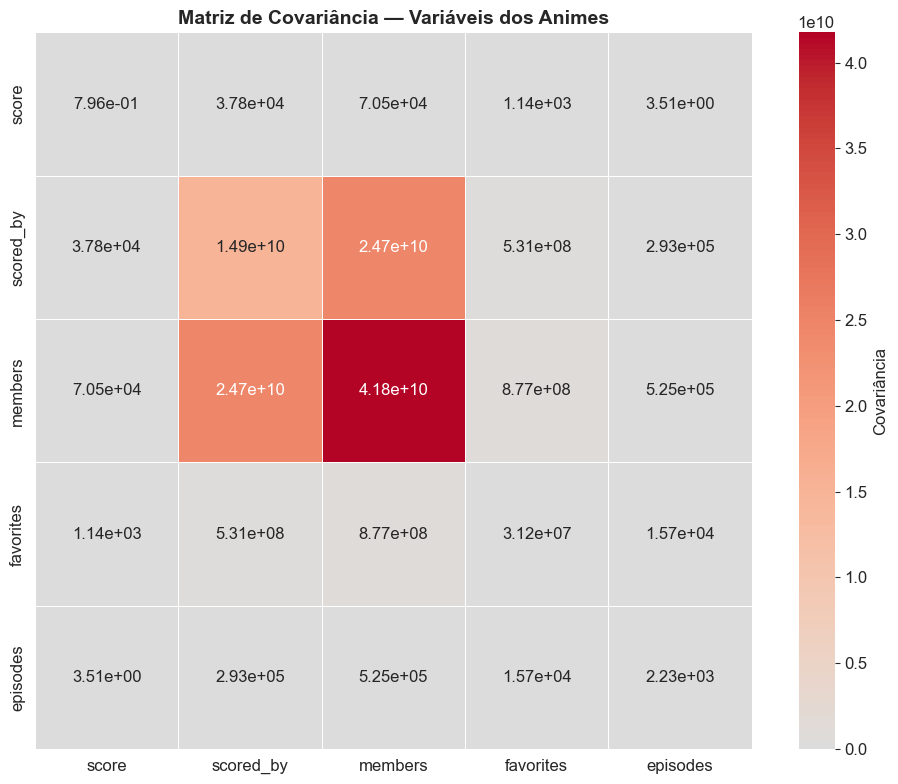


Nota: Os valores de covariância são muito grandes porque as escalas das variáveis são diferentes.
Para uma interpretação mais fácil, vamos analisar as correlações normalizadas.


In [22]:
# Covariance matrix visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, fmt='.2e', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Covariance'})
ax.set_title('Covariance Matrix — Anime Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: Covariance values are very large because variable scales are different.")
print("For easier interpretation, we will analyze normalized correlations.")

## 2.5 Correlation Analysis (Pearson)

Pearson's correlation coefficient (r) normalizes covariance, producing values between -1 and +1:
- **r ≈ +1**: strong positive correlation
- **r ≈ 0**: no linear correlation  
- **r ≈ -1**: strong negative correlation

$$r_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

In [23]:
# Pearson correlation matrix
corr_vars = ['score', 'scored_by', 'members', 'favorites', 'episodes', 'rank', 'popularity']
corr_matrix = details_scored[corr_vars].corr(method='pearson')

print("=== Pearson Correlation Matrix (Anime) ===\n")
print(corr_matrix.round(4).to_string())

=== Matriz de Correlação de Pearson (Animes) ===

            score  scored_by  members  favorites  episodes  rank  popularity
score        1.00       0.35     0.39       0.23      0.08 -0.98       -0.66
scored_by    0.35       1.00     0.99       0.78      0.05 -0.33       -0.36
members      0.39       0.99     1.00       0.77      0.05 -0.37       -0.42
favorites    0.23       0.78     0.77       1.00      0.06 -0.20       -0.19
episodes     0.08       0.05     0.05       0.06      1.00 -0.06       -0.06
rank        -0.98      -0.33    -0.37      -0.20     -0.06  1.00        0.71
popularity  -0.66      -0.36    -0.42      -0.19     -0.06  0.71        1.00


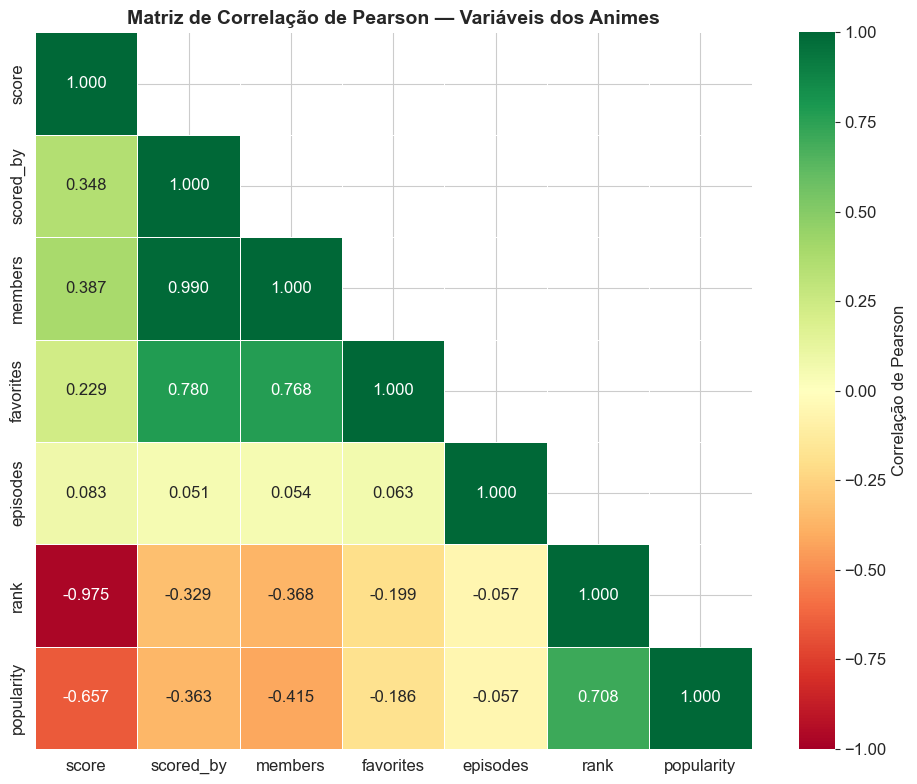

In [24]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, mask=mask, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Pearson Correlation Matrix — Anime Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Identify strongest correlations (excluding diagonal)
print("=== Top 10 Strongest Correlations ===\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        r = corr_matrix.iloc[i, j]
        corr_pairs.append((var1, var2, r, abs(r)))

corr_pairs.sort(key=lambda x: x[3], reverse=True)

for var1, var2, r, abs_r in corr_pairs[:10]:
    direction = "positive" if r > 0 else "negative"
    strength = "strong" if abs_r > 0.7 else ("moderate" if abs_r > 0.4 else "weak")
    print(f"  {var1:12s} <-> {var2:12s} : r = {r:+.4f} (correlation {strength} {direction})")

=== Top 10 Correlações Mais Fortes ===

  scored_by    <-> members      : r = +0.9895 (correlacao forte positiva)
  score        <-> rank         : r = -0.9752 (correlacao forte negativa)
  scored_by    <-> favorites    : r = +0.7802 (correlacao forte positiva)
  members      <-> favorites    : r = +0.7682 (correlacao forte positiva)
  rank         <-> popularity   : r = +0.7082 (correlacao forte positiva)
  score        <-> popularity   : r = -0.6566 (correlacao moderada negativa)
  members      <-> popularity   : r = -0.4153 (correlacao moderada negativa)
  score        <-> members      : r = +0.3867 (correlacao fraca positiva)
  members      <-> rank         : r = -0.3682 (correlacao fraca negativa)
  scored_by    <-> popularity   : r = -0.3625 (correlacao fraca negativa)


## 2.6 Statistical Analysis by Anime Type

Let's compare statistical measures across different anime types (TV, Movie, OVA, etc.).

In [26]:
# Statistics by anime type
type_stats = details_scored.groupby('type').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    std_score=('score', 'std'),
    var_score=('score', 'var'),
    avg_members=('members', 'mean'),
    std_members=('members', 'std'),
    avg_favorites=('favorites', 'mean'),
    avg_episodes=('episodes', 'mean')
).round(4)

type_stats = type_stats.sort_values('count', ascending=False)
print("=== Statistics by Anime Type ===\n")
type_stats

=== Estatísticas por Tipo de Anime ===



,contagem,score_medio,score_mediano,score_std,score_var,membros_medio,membros_std,favoritos_medio,episodios_medio
type,,,,,,,,,
TV,5122,6.83,6.82,0.81,0.65,166117.40,350698.05,2123.68,30.35
OVA,3500,6.23,6.22,0.80,0.65,17715.86,45383.72,77.42,2.45
Movie,2847,6.36,6.35,1.07,1.15,41479.35,141401.03,332.22,1.10
ONA,2398,6.25,6.21,0.90,0.81,13992.52,51509.17,98.25,13.26
Music,2343,5.95,5.93,0.67,0.45,1328.10,7399.53,3.97,1.11
Special,1492,6.40,6.41,0.73,0.53,19764.64,40535.54,26.53,2.85
TV Special,593,6.47,6.44,0.74,0.55,23796.06,64645.90,89.23,1.42
CM,382,5.69,5.62,0.57,0.33,2484.90,5387.07,4.24,2.39
PV,204,6.09,5.97,0.77,0.59,3747.71,8902.59,18.51,1.20


## 2.7 Covariance and Correlation — Viewing Statistics (stats.csv)

Let's analyze the relationship between stats.csv variables, namely viewing states and vote distribution.

Registos após merge details+stats: 18,882


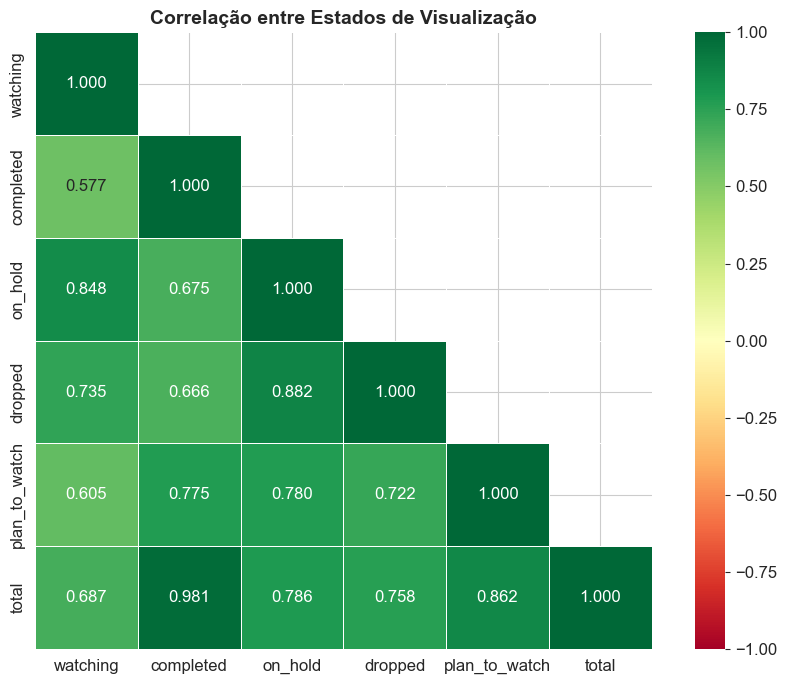

In [27]:
# Merge details with stats for joint analysis
details_stats = details_scored.merge(stats, on='mal_id', how='inner')
print(f"Records after details+stats merge: {len(details_stats):,}")

# Covariance between viewing status variables
view_vars = ['watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch', 'total']
view_corr = details_stats[view_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(view_corr, dtype=bool), k=1)
sns.heatmap(view_corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, mask=mask, vmin=-1, vmax=1)
ax.set_title('Correlation between Viewing States', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Correlation between score and voting percentages
score_pct_vars = ['score_1_percentage', 'score_2_percentage', 'score_3_percentage',
                  'score_4_percentage', 'score_5_percentage', 'score_6_percentage',
                  'score_7_percentage', 'score_8_percentage', 'score_9_percentage',
                  'score_10_percentage']

# Correlation of each score range with average anime score
print("=== Correlation between Average Score and Vote Distribution ===\n")
for pct_col in score_pct_vars:
    score_num = pct_col.replace('score_', '').replace('_percentage', '')
    r = details_stats['score'].corr(details_stats[pct_col])
    bar = '#' * int(abs(r) * 30)
    sign = '+' if r > 0 else '-'
    print(f"  Score {score_num:>2s} %: r = {r:+.4f}  {sign}{bar}")

=== Correlação entre Score Médio e Distribuição de Votos ===

  Score  1 %: r = -0.7154  -#####################
  Score  2 %: r = -0.7694  -#######################
  Score  3 %: r = -0.8265  -########################
  Score  4 %: r = -0.8528  -#########################
  Score  5 %: r = -0.7971  -#######################
  Score  6 %: r = -0.2847  -########
  Score  7 %: r = +0.6798  +####################
  Score  8 %: r = +0.8830  +##########################
  Score  9 %: r = +0.8091  +########################
  Score 10 %: r = +0.5297  +###############


## 2.8 Correlation — User Profiles

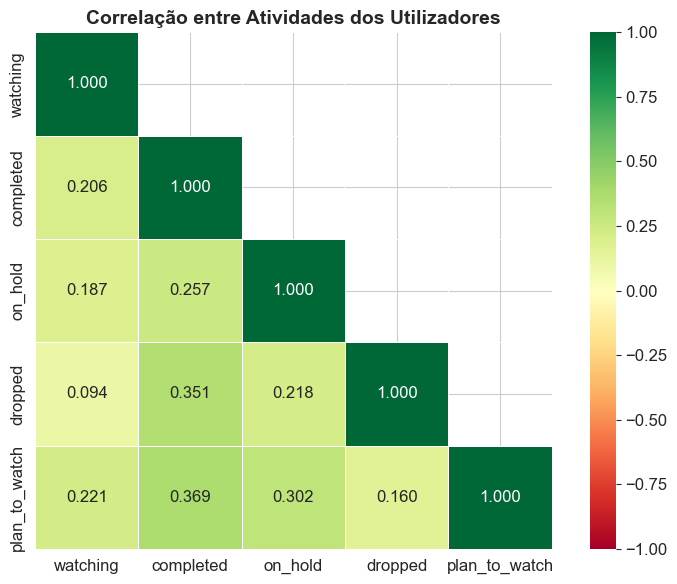


=== Interpretação ===
  completed <-> dropped: r=0.351 (correlacao moderada positiva)
  completed <-> plan_to_watch: r=0.369 (correlacao moderada positiva)
  on_hold <-> plan_to_watch: r=0.302 (correlacao moderada positiva)


In [29]:
# Correlation between user activities
profile_corr_vars = ['watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch']
profile_corr = profiles[profile_corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(profile_corr, dtype=bool), k=1)
sns.heatmap(profile_corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, ax=ax, mask=mask, vmin=-1, vmax=1)
ax.set_title('Correlation between User Activities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations
print("\n=== Interpretation ===")
for i in range(len(profile_corr.columns)):
    for j in range(i+1, len(profile_corr.columns)):
        r = profile_corr.iloc[i, j]
        if abs(r) > 0.3:
            v1, v2 = profile_corr.columns[i], profile_corr.columns[j]
            strength = "strong" if abs(r) > 0.7 else "moderate"
            direction = "positive" if r > 0 else "negative"
            print(f"  {v1} <-> {v2}: r={r:.3f} (correlation {strength} {direction})")

## 2.9 Covariance — User Profiles

=== Matriz de Covariância (Perfis de Utilizadores) ===

               watching  completed  on_hold  dropped  plan_to_watch
watching        1805.74    1699.51   257.43   156.68        1300.26
completed       1699.51   43942.92  1558.00  2420.43       10707.24
on_hold          257.43    1558.00  1074.53   278.46        1310.13
dropped          156.68    2420.43   278.46  1566.00         889.68
plan_to_watch   1300.26   10707.24  1310.13   889.68       20946.33


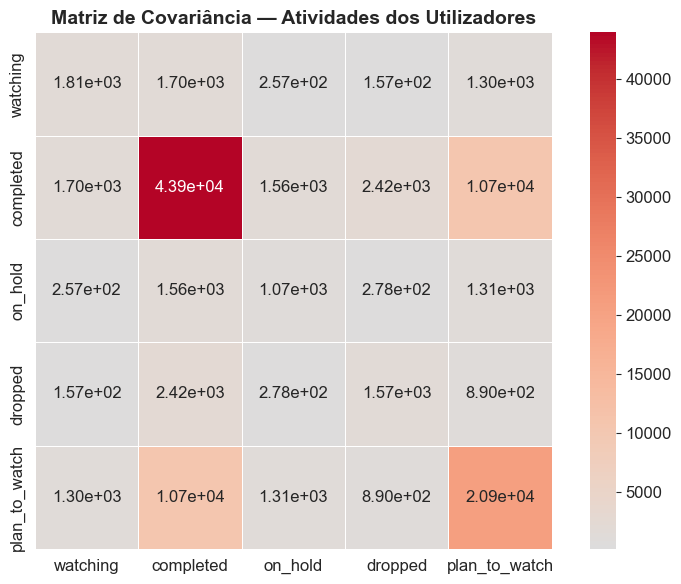

In [30]:
# Profile covariance matrix
profile_cov = profiles[profile_corr_vars].cov()

print("=== Covariance Matrix (User Profiles) ===\n")
print(profile_cov.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(profile_cov, annot=True, fmt='.2e', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Covariance Matrix — User Activities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


[⬆ Back to Index](#-table-of-contents)

---

---
# 3. Feature Engineering — Creating New Variables

In this section we create new features derived from existing variables to enrich the analysis and prepare the dataset for Machine Learning models in Part II.

For this, we first merge the main data.

In [31]:
# Merge details (with valid scores) + stats to create enriched dataset
df = details_scored.merge(stats, on='mal_id', how='left', suffixes=('', '_stats'))
print(f"Combined dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset combinado: 18,882 linhas × 55 colunas


,mal_id,title,title_japanese,url,image_url,type,status,score,scored_by,start_date,end_date,synopsis,rank,popularity,members,favorites,genres,studios,themes,demographics,source,rating,episodes,season,year,...,completed,on_hold,dropped,plan_to_watch,total,score_1_votes,score_1_percentage,score_2_votes,score_2_percentage,score_3_votes,score_3_percentage,score_4_votes,score_4_percentage,score_5_votes,score_5_percentage,score_6_votes,score_6_percentage,score_7_votes,score_7_percentage,score_8_votes,score_8_percentage,score_9_votes,score_9_percentage,score_10_votes,score_10_percentage
0,56036,......,......,https://myanimelist.net/anime/56036/-,https://cdn.myanimelist.net/images/anime/1057/...,Music,Finished Airing,6.53,503.00,2023-06-11T00:00:00+00:00,NaN,Music video directed by obmolot for the song ....,NaN,15004,941,2,"['Horror', 'Supernatural']",['Flat Studio'],['Music'],[],Original,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,770,8,29,113,941,5.00,1.00,6.00,1.20,8.00,1.60,14.00,2.80,50.00,9.90,138.00,27.40,144.00,28.60,81.00,16.10,17.00,3.40,40.00,8.00
1,2928,.hack//G.U. Returner,.HACK//G.U. RETURNER,https://myanimelist.net/anime/2928/hack__GU_Re...,https://cdn.myanimelist.net/images/anime/1798/...,OVA,Finished Airing,6.65,9745.00,2007-01-18T00:00:00+00:00,NaN,The characters from previous .hack//G.U. Games...,6366.00,5056,22525,31,"['Adventure', 'Drama', 'Fantasy']",['Bee Train'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,14953,302,349,6472,22527,101.00,1.00,93.00,1.00,164.00,1.70,457.00,4.70,1184.00,12.10,2054.00,21.10,2709.00,27.80,1500.00,15.40,875.00,9.00,608.00,6.20
2,3269,.hack//G.U. Trilogy,.hack//G.U. Trilogy,https://myanimelist.net/anime/3269/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/1566/...,Movie,Finished Airing,7.06,15373.00,2007-12-22T00:00:00+00:00,NaN,"Based on the CyberConnect2 HIT GAME, now will ...",4194.00,4215,34264,104,"['Action', 'Fantasy']",['CyberConnect2'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,22790,452,537,9762,34267,120.00,0.80,156.00,1.00,260.00,1.70,560.00,3.60,1270.00,8.30,2457.00,16.00,4157.00,27.00,3075.00,20.00,1919.00,12.50,1400.00,9.10


## 3.1 Engagement Ratios

In [32]:
# --- Engagement_Ratio ---
# Percentage of members who marked as favorite
df['Engagement_Ratio'] = df['favorites'] / df['members']
df['Engagement_Ratio'] = df['Engagement_Ratio'].replace([np.inf, -np.inf], np.nan)

# --- Hype_vs_Action_Ratio ---
# Ratio between actual raters and list adders
df['Hype_vs_Action_Ratio'] = df['scored_by'] / df['members']
df['Hype_vs_Action_Ratio'] = df['Hype_vs_Action_Ratio'].replace([np.inf, -np.inf], np.nan)

# --- Completion_Ratio ---
# Percentage of members who completed the anime
df['Completion_Ratio'] = df['completed'] / df['total']
df['Completion_Ratio'] = df['Completion_Ratio'].replace([np.inf, -np.inf], np.nan)

# --- Backlog_Ratio ---
# Percentage of members with "plan to watch" who haven't started
df['Backlog_Ratio'] = df['plan_to_watch'] / df['total']
df['Backlog_Ratio'] = df['Backlog_Ratio'].replace([np.inf, -np.inf], np.nan)

print("=== Engagement Ratios — Statistics ===\n")
ratio_cols = ['Engagement_Ratio', 'Hype_vs_Action_Ratio', 'Completion_Ratio', 'Backlog_Ratio']
print(df[ratio_cols].describe().round(4).to_string())

print("\n\n=== Top 10 Anime by Engagement_Ratio (most loved) ===")
top_engaged = df[df['members'] > 1000].nlargest(10, 'Engagement_Ratio')[['title', 'score', 'members', 'favorites', 'Engagement_Ratio']]
print(top_engaged.to_string(index=False))

print("\n\n=== Top 10 Anime by Backlog_Ratio (most procrastinated) ===")
top_backlog = df[df['members'] > 10000].nlargest(10, 'Backlog_Ratio')[['title', 'score', 'members', 'Backlog_Ratio']]
print(top_backlog.to_string(index=False))

=== Ratios de Engagement — Estatísticas ===

       Engagement_Ratio  Hype_vs_Action_Ratio  Completion_Ratio  Backlog_Ratio
count          18882.00              18882.00          18882.00       18882.00
mean               0.00                  0.40              0.55           0.30
std                0.00                  0.11              0.18           0.13
min                0.00                  0.02              0.00           0.02
25%                0.00                  0.32              0.43           0.20
50%                0.00                  0.40              0.55           0.29
75%                0.00                  0.49              0.69           0.38
max                0.09                  0.90              0.97           0.95


=== Top 10 Animes por Engagement_Ratio (mais amados) ===
                           title  score  members  favorites  Engagement_Ratio
                       One Piece   8.73  2581334     243358              0.09
          Hunter x Hunter (20

## 3.2 Score Classifications and Tiers

In [33]:
# --- Score_Tier ---
# Categorical score classification for classification algorithms
bins = [0, 4, 6, 8, 10]
labels = ['Poor (< 4)', 'Below Average (4-6)', 'Good (6-8)', 'Great/Masterpiece (8-10)']
df['Score_Tier'] = pd.cut(df['score'], bins=bins, labels=labels, include_lowest=True)

print("=== Distribution by Score Tier ===\n")
tier_dist = df['Score_Tier'].value_counts().sort_index()
for tier, count in tier_dist.items():
    pct = count / len(df) * 100
    bar = '#' * int(pct / 2)
    print(f"  {tier:30s}: {count:>6,} ({pct:5.1f}%) {bar}")

# --- Mature_Content_Flag ---
# Flag for mature content (R-17+ and Rx-Hentai)
df['Mature_Content_Flag'] = df['rating'].apply(
    lambda x: 1 if pd.notna(x) and ('R - 17+' in str(x) or 'Rx - Hentai' in str(x)) else 0
)

print(f"\n=== Mature Content Flag ===")
print(f"  Mature content (R-17+ / Rx): {df['Mature_Content_Flag'].sum():,} ({df['Mature_Content_Flag'].mean()*100:.1f}%)")
print(f"  Average score (Mature):         {df[df['Mature_Content_Flag']==1]['score'].mean():.2f}")
print(f"  Average score (Non-mature):     {df[df['Mature_Content_Flag']==0]['score'].mean():.2f}")

=== Distribuição por Score Tier ===

  Poor (< 4)                    :     99 (  0.5%) 
  Below Average (4-6)           :  6,373 ( 33.8%) ################
  Good (6-8)                    : 11,715 ( 62.0%) ###############################
  Great/Masterpiece (8-10)      :    695 (  3.7%) #

=== Mature Content Flag ===
  Conteúdo maduro (R-17+ / Rx): 3,008 (15.9%)
  Score médio (Maduro):         6.52
  Score médio (Não maduro):     6.37


## 3.3 Temporal Features

In [34]:
# --- Release_Season ---
# The 'season' column already exists, but we clean and use it
df['Release_Season'] = df['season'].fillna('Unknown')

print("=== Distribution by Season ===\n")
season_dist = df['Release_Season'].value_counts()
for s, c in season_dist.items():
    avg_score = df[df['Release_Season']==s]['score'].mean()
    print(f"  {s:10s}: {c:>6,} anime | Avg Score: {avg_score:.2f}")

# --- Release_Era ---
# Categorization into historical eras
def categorize_era(year):
    if pd.isna(year):
        return 'Unknown'
    elif year < 2000:
        return 'Classic (Pre-2000)'
    elif year <= 2010:
        return 'Golden Age (2000-2010)'
    elif year <= 2020:
        return 'Modern (2011-2020)'
    else:
        return 'Current (2021+)'

df['Release_Era'] = df['year'].apply(categorize_era)

print("\n=== Distribution by Era ===\n")
era_dist = df['Release_Era'].value_counts()
for era, c in era_dist.items():
    avg_score = df[df['Release_Era']==era]['score'].mean()
    avg_members = df[df['Release_Era']==era]['members'].mean()
    print(f"  {era:25s}: {c:>6,} anime | Score: {avg_score:.2f} | Avg members: {avg_members:,.0f}")

# --- Anime_Age_Years ---
df['Anime_Age_Years'] = 2026 - df['year']

# --- Popularity_to_Age_Ratio ---
# Members gained per year of existence
df['Popularity_to_Age_Ratio'] = df['members'] / df['Anime_Age_Years']
df['Popularity_to_Age_Ratio'] = df['Popularity_to_Age_Ratio'].replace([np.inf, -np.inf], np.nan)

print("\n=== Top 10 Anime with Highest Popularity Growth (members/year) ===")
top_growth = df[df['Anime_Age_Years'] > 0].nlargest(10, 'Popularity_to_Age_Ratio')[
    ['title', 'year', 'members', 'Anime_Age_Years', 'Popularity_to_Age_Ratio']
]
print(top_growth.to_string(index=False))

=== Distribuição por Season ===

  Unknown   : 13,800 animes | Score médio: 6.22
  spring    :  1,618 animes | Score médio: 6.85


  fall      :  1,475 animes | Score médio: 6.88
  winter    :  1,047 animes | Score médio: 6.80
  summer    :    942 animes | Score médio: 6.82

=== Distribuição por Era ===



  Unknown                  : 13,800 animes | Score: 6.22 | Membros médio: 18,994
  Modern (2011-2020)       :  1,911 animes | Score: 6.79 | Membros médio: 255,661
  Golden Age (2000-2010)   :  1,225 animes | Score: 6.92 | Membros médio: 132,851
  Current (2021+)          :  1,006 animes | Score: 6.99 | Membros médio: 168,537
  Classic (Pre-2000)       :    940 animes | Score: 6.68 | Membros médio: 31,868

=== Top 10 Animes com Maior Crescimento de Popularidade (membros/ano) ===


                                                   title    year  members  Anime_Age_Years  Popularity_to_Age_Ratio
Ore dake Level Up na Ken Season 2: Arise from the Shadow 2025.00   669433             1.00                669433.00
                                Ore dake Level Up na Ken 2024.00  1032903             2.00                516451.50
                                          Jujutsu Kaisen 2020.00  2880058             6.00                480009.67
                                        Kimetsu no Yaiba 2019.00  3323322             7.00                474760.29
                                            Chainsaw Man 2022.00  1813584             4.00                453396.00
                                            Spy x Family 2022.00  1794468             4.00                448617.00
                    Shingeki no Kyojin: The Final Season 2021.00  2201893             5.00                440378.60
                                           Sakamoto Days 2025.00   43289

## 3.4 Hidden Gems, Mainstream Giants & Underrated

In [35]:
# --- Hidden_Gem_Flag ---
# Top 20% score but bottom 50% popularity
score_80th = df['score'].quantile(0.80)
popularity_50th = df['popularity'].quantile(0.50)  # higher rank = less popular
df['Hidden_Gem_Flag'] = ((df['score'] >= score_80th) & (df['popularity'] >= popularity_50th)).astype(int)

print(f"=== Hidden Gems ===")
print(f"  Criteria: score >= {score_80th:.2f} AND popularity rank >= {popularity_50th:.0f}")
print(f"  Total Hidden Gems: {df['Hidden_Gem_Flag'].sum():,}")
print(f"\n  Top 15 Hidden Gems (by score):")
hidden_gems = df[df['Hidden_Gem_Flag']==1].nlargest(15, 'score')[['title', 'score', 'members', 'popularity', 'type']]
print(hidden_gems.to_string(index=False))

# --- Rank_Popularity_Gap ---
# Difference between popularity rank and score rank
df['Rank_Popularity_Gap'] = df['popularity'] - df['rank']

print(f"\n\n=== Rank-Popularity Gap ===")
print(f"  High positive value = Hidden Gem (well rated but unpopular)")
print(f"  High negative value = Mainstream but poorly rated")
print(f"\n  Top 10 'Hidden Gems' (Positive gap):")
top_gap = df.dropna(subset=['rank', 'popularity']).nlargest(10, 'Rank_Popularity_Gap')[['title', 'score', 'rank', 'popularity', 'Rank_Popularity_Gap']]
print(top_gap.to_string(index=False))

print(f"\n  Top 10 'Overhyped' (Negative gap):")
bottom_gap = df.dropna(subset=['rank', 'popularity']).nsmallest(10, 'Rank_Popularity_Gap')[['title', 'score', 'rank', 'popularity', 'Rank_Popularity_Gap']]
print(bottom_gap.to_string(index=False))

=== Hidden Gems ===
  Critério: score >= 7.18 AND popularity rank >= 9694
  Total de Hidden Gems: 266

  Top 15 Hidden Gems (por score):
                                         title  score  members  popularity  type
         Fanren Xiu Xian Chuan: Xinghai Feichi   8.27     3278       10583   ONA
         Fanren Xiu Xian Chuan: Waihai Fengyun   8.24     1945       12409   ONA
                  Yi Nian Yong Heng 3rd Season   8.19     3450       10422   ONA
                       Cang Yuan Tu 2nd Season   8.13     1801       12633   ONA
                     Precure All Stars Movie F   8.10     4329        9703 Movie
Aikatsu! 10th Story: Mirai e no Starway (2023)   7.95     2818       11122 Movie
 Benghuai: Xing Qiong Tiedao - Gelamo de Yujin   7.95     2960       10957   ONA
            Tunshi Xingkong Movie: Xueluo Dalu   7.95     1736       12742   ONA
                           Zhu Xian 2nd Season   7.93     2970       10942   ONA
 IDOLiSH7 Movie: LIVE 4bit - BEYOND THE PERiOD   7.90

                             title  score    rank  popularity  Rank_Popularity_Gap
               Sono Saki no Taniji   6.71 5966.00       21665             15699.00
           You Shou Yan 3rd Season   7.79 1098.00       15995             14897.00
           You Shou Yan 4th Season   7.64 1504.00       16246             14742.00
    Douluo Dalu: Daoyan Jianji Ban   7.35 2657.00       17146             14489.00
    Shixiong A Shixiong 3rd Season   7.19 3503.00       17813             14310.00
                      Aka no Kioku   6.56 6906.00       20738             13832.00
           You Shou Yan 2nd Season   7.61 1593.00       15239             13646.00
       Hate no Issen: Episode Zero   6.65 6387.00       19903             13516.00
              Ling Long 2nd Season   7.67 1423.00       14870             13447.00
Li Linke de Xiao Guaner 2nd Season   7.40 2444.00       15880             13436.00

  Top 10 'Overhyped' (Gap negativo):


                                          title  score     rank  popularity  Rank_Popularity_Gap
               Yakusoku no Neverland 2nd Season   5.25 13230.00         190            -13040.00
                                           Pupa   3.28 14297.00        1350            -12947.00
                                Diabolik Lovers   5.18 13374.00         713            -12661.00
                      Ousama Game The Animation   5.08 13554.00        1031            -12523.00
                                     Conception   4.57 14072.00        1861            -12211.00
                                    School Days   5.51 12451.00         327            -12124.00
Ore ga Suki nano wa Imouto dakedo Imouto ja Nai   4.88 13784.00        1774            -12010.00
                                 Big Order (TV)   5.35 12954.00        1116            -11838.00
                          Isekai Cheat Magician   5.48 12544.00         741            -11803.00
                              

In [36]:
# --- Mainstream_Giant_Flag ---
# Top 10% score AND top 10% popularity
score_90th = df['score'].quantile(0.90)
popularity_10th = df['popularity'].quantile(0.10)  # lower rank = more popular
df['Mainstream_Giant_Flag'] = ((df['score'] >= score_90th) & (df['popularity'] <= popularity_10th)).astype(int)

print(f"=== Mainstream Giants ===")
print(f"  Criteria: score >= {score_90th:.2f} AND popularity rank <= {popularity_10th:.0f}")
print(f"  Total: {df['Mainstream_Giant_Flag'].sum():,}")
print(f"\n  Mainstream Giants:")
mainstream = df[df['Mainstream_Giant_Flag']==1].nlargest(20, 'score')[['title', 'score', 'members', 'popularity']]
print(mainstream.to_string(index=False))

# --- Underrated Filter ---
# High score + low popularity (high rank)
score_75th = df['score'].quantile(0.75)
popularity_75th = df['popularity'].quantile(0.75)
df['Underrated_Flag'] = ((df['score'] >= score_75th) & (df['popularity'] >= popularity_75th)).astype(int)

print(f"\n\n=== Underrated Anime ===")
print(f"  Criteria: score >= {score_75th:.2f} AND popularity rank >= {popularity_75th:.0f}")
print(f"  Total: {df['Underrated_Flag'].sum():,}")

=== Mainstream Giants ===
  Critério: score >= 7.55 AND popularity rank <= 1896
  Total: 929

  Mainstream Giants:
                                     title  score  members  popularity
                         Sousou no Frieren   9.29  1223219         129
          Fullmetal Alchemist: Brotherhood   9.10  3576199           3
                               Steins;Gate   9.07  2737090          14
                        Gintama: The Final   9.05   174624        1519
                                  Gintama°   9.05   676093         344
        Shingeki no Kyojin Season 3 Part 2   9.05  2496631          21
                    Hunter x Hunter (2011)   9.03  3080867           8
                      Ginga Eiyuu Densetsu   9.02   350634         752
                                  Gintama'   9.02   598122         405
                       Gintama': Enchousen   9.02   349944         753
                 Bleach: Sennen Kessen-hen   8.99   660380         359
                                 

## 3.5 Studio and Source Material Features

In [37]:
# --- Top_Tier_Studio_Flag ---
# List of historically well-rated studios
top_studios = ['Madhouse', 'Ufotable', 'Kyoto Animation', 'MAPPA', 'Bones', 
               'Wit Studio', 'Production I.G', 'A-1 Pictures', 'Studio Ghibli',
               'Sunrise', 'Toei Animation', 'CloverWorks']

def check_top_studio(studios_str):
    if pd.isna(studios_str):
        return 0
    for studio in top_studios:
        if studio.lower() in str(studios_str).lower():
            return 1
    return 0

df['Top_Tier_Studio_Flag'] = df['studios'].apply(check_top_studio)

print(f"=== Top Tier Studio ===")
print(f"  Anime from top studios: {df['Top_Tier_Studio_Flag'].sum():,} ({df['Top_Tier_Studio_Flag'].mean()*100:.1f}%)")
print(f"  Avg score (Top studio):     {df[df['Top_Tier_Studio_Flag']==1]['score'].mean():.2f}")
print(f"  Avg score (Others):         {df[df['Top_Tier_Studio_Flag']==0]['score'].mean():.2f}")
print(f"  Avg members (Top studio):   {df[df['Top_Tier_Studio_Flag']==1]['members'].mean():,.0f}")
print(f"  Avg members (Others):       {df[df['Top_Tier_Studio_Flag']==0]['members'].mean():,.0f}")

# --- Source_Material_Encoded ---
# Group sources into broader categories
def encode_source(source):
    if pd.isna(source):
        return 'Unknown'
    s = str(source).lower()
    if any(x in s for x in ['manga', 'light novel', 'novel', 'book', '4-koma manga', 'web manga']):
        return 'Printed Text'
    elif any(x in s for x in ['visual novel', 'game', 'card game']):
        return 'Digital/Game'
    elif 'original' in s:
        return 'Original'
    elif any(x in s for x in ['music', 'radio', 'picture book']):
        return 'Other Media'
    elif 'web novel' in s:
        return 'Printed Text'
    else:
        return 'Other'

df['Source_Material_Encoded'] = df['source'].apply(encode_source)

print(f"\n=== Source Material Distribution ===\n")
source_dist = df['Source_Material_Encoded'].value_counts()
for src, c in source_dist.items():
    avg_score = df[df['Source_Material_Encoded']==src]['score'].mean()
    print(f"  {src:15s}: {c:>6,} anime | Avg Score: {avg_score:.2f}")

=== Top Tier Studio ===
  Animes de estúdios top: 2,988 (15.8%)
  Score médio (Top studio):     6.91
  Score médio (Outros):         6.29
  Membros médio (Top studio):   139,437
  Membros médio (Outros):       43,809



=== Source Material Distribution ===



  Printed Text   :  8,957 animes | Score médio: 6.74


  Original       :  6,288 animes | Score médio: 6.07
  Other          :  2,117 animes | Score médio: 5.99
  Digital/Game   :  1,291 animes | Score médio: 6.33
  Other Media    :    229 animes | Score médio: 5.60


## 3.6 Genre Features

In [38]:
import ast

# Function to parse genre lists (string to list format)
def parse_list_col(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return [val]

# --- Genre_Mainstream_Index ---
# Score based on number of "popular" genres the anime has
mainstream_genres = ['Action', 'Comedy', 'Fantasy', 'Adventure', 'Romance', 
                     'Drama', 'Sci-Fi', 'Slice of Life', 'Supernatural']

def calc_genre_mainstream_index(genres_str):
    genres = parse_list_col(genres_str)
    count = sum(1 for g in genres if any(mg.lower() in g.lower() for mg in mainstream_genres))
    return count

df['Genre_Mainstream_Index'] = df['genres'].apply(calc_genre_mainstream_index)

print("=== Genre Mainstream Index (count of popular genres) ===\n")
gmi_dist = df['Genre_Mainstream_Index'].value_counts().sort_index()
for idx, c in gmi_dist.items():
    avg_score = df[df['Genre_Mainstream_Index']==idx]['score'].mean()
    avg_members = df[df['Genre_Mainstream_Index']==idx]['members'].mean()
    print(f"  Index {idx}: {c:>6,} anime | Score: {avg_score:.2f} | Members: {avg_members:,.0f}")

# --- Is_Isekai_Flag ---
# Detect isekai anime via synopsis, genres, and themes
isekai_keywords = ['isekai', 'reincarnated', 'another world', 'transported to', 
                   'summoned to', 'reborn in', 'parallel world', 'virtual world']

def check_isekai(row):
    text = ''
    for col in ['synopsis', 'genres', 'themes']:
        if pd.notna(row.get(col)):
            text += ' ' + str(row[col]).lower()
    return int(any(kw in text for kw in isekai_keywords))

df['Is_Isekai_Flag'] = df.apply(check_isekai, axis=1)

print(f"\n=== Isekai Flag ===")
print(f"  Isekai anime detected: {df['Is_Isekai_Flag'].sum():,}")
print(f"  Avg score (Isekai):     {df[df['Is_Isekai_Flag']==1]['score'].mean():.2f}")
print(f"  Avg score (Non-Isekai): {df[df['Is_Isekai_Flag']==0]['score'].mean():.2f}")

# Isekai por era
print(f"\n  Isekai by Era:")
isekai_era = df[df['Is_Isekai_Flag']==1].groupby('Release_Era').size()
for era, c in isekai_era.items():
    print(f"    {era}: {c}")

=== Genre Mainstream Index (contagem de géneros populares) ===

  Index 0:  5,004 animes | Score: 6.00 | Membros: 14,841
  Index 1:  5,673 animes | Score: 6.28 | Membros: 39,895
  Index 2:  4,586 animes | Score: 6.59 | Membros: 90,156
  Index 3:  2,676 animes | Score: 6.85 | Membros: 112,287
  Index 4:    811 animes | Score: 6.84 | Membros: 109,862
  Index 5:    115 animes | Score: 6.87 | Membros: 78,687
  Index 6:     17 animes | Score: 6.93 | Membros: 15,485



=== Isekai Flag ===
  Animes Isekai detectados: 558
  Score médio (Isekai):     6.81
  Score médio (Non-Isekai): 6.38

  Isekai por Era:
    Classic (Pre-2000): 32
    Current (2021+): 143
    Golden Age (2000-2010): 44
    Modern (2011-2020): 95
    Unknown: 244


## 3.7 Binge-ability Calculator

> **Note:** The dataset does not contain a `duration` column (duration per episode), so we estimate based on anime type:
> - TV: ~24 min/episode
> - Movie: ~90 min
> - OVA/ONA: ~25 min/episode  
> - Special: ~20 min/episode
> - Music: ~4 min

In [39]:
# Duration estimate by type
duration_map = {
    'TV': 24, 'Movie': 90, 'OVA': 25, 'ONA': 25,
    'Special': 20, 'Music': 4, 'TV Short': 5, 'CM': 1, 'PV': 2
}

df['Est_Duration_Min'] = df['type'].map(duration_map).fillna(24)

# --- Total_Watch_Time_Hours ---
df['Total_Watch_Time_Hours'] = (df['episodes'] * df['Est_Duration_Min']) / 60
df['Total_Watch_Time_Hours'] = df['Total_Watch_Time_Hours'].replace([np.inf, -np.inf], np.nan)

# --- Binge_Category ---
def categorize_binge(hours):
    if pd.isna(hours) or hours <= 0:
        return 'Unknown'
    elif hours <= 2:
        return 'Quick Watch (< 2h)'
    elif hours <= 5:
        return 'Weekend Binge (2-5h)'
    elif hours <= 13:
        return 'Week Binge (5-13h)'
    elif hours <= 50:
        return 'Standard Series (13-50h)'
    else:
        return 'Long Commitment (50+ h)'

df['Binge_Category'] = df['Total_Watch_Time_Hours'].apply(categorize_binge)

print("=== Binge-ability Categories ===\n")
binge_dist = df['Binge_Category'].value_counts()
for cat, c in binge_dist.items():
    avg_score = df[df['Binge_Category']==cat]['score'].mean()
    avg_completion = df[df['Binge_Category']==cat]['Completion_Ratio'].mean()
    print(f"  {cat:30s}: {c:>6,} | Score: {avg_score:.2f} | Completion: {avg_completion:.2%}")

print(f"\n=== Top 10 Longest Anime (estimated hours) ===")
longest = df.nlargest(10, 'Total_Watch_Time_Hours')[['title', 'episodes', 'type', 'Total_Watch_Time_Hours', 'score']]
print(longest.to_string(index=False))

=== Binge-ability Categories ===

  Quick Watch (< 2h)            : 11,837 | Score: 6.16 | Completion: 60.54%
  Weekend Binge (2-5h)          :  3,162 | Score: 6.69 | Completion: 48.68%
  Week Binge (5-13h)            :  2,483 | Score: 6.88 | Completion: 46.32%
  Standard Series (13-50h)      :  1,151 | Score: 6.76 | Completion: 43.80%
  Long Commitment (50+ h)       :    128 | Score: 6.91 | Completion: 38.50%
  Unknown                       :    121 | Score: 6.61 | Completion: 0.43%

=== Top 10 Longest Animes (estimated hours) ===
                                title  episodes type  Total_Watch_Time_Hours  score
                              Lan Mao   3000.00   TV                 1200.00   6.06
                           Oyako Club   1818.00   TV                  727.20   5.45
                      Doraemon (1979)   1787.00   TV                  714.80   7.88
                             Gudetama   1717.00   TV                  686.80   6.61
               Kirin Monoshiri Yakata   15

## 3.8 Summary of Created Features

In [40]:
# List of all new features
new_features = {
    'Engagement_Ratio': 'favorites / members — Percentage who loved the anime',
    'Hype_vs_Action_Ratio': 'scored_by / members — Actual raters vs. list adders',
    'Completion_Ratio': 'completed / total — Percentage who completed the anime',
    'Backlog_Ratio': 'plan_to_watch / total — Percentage in backlog',
    'Score_Tier': 'Categorical score classification (Poor/Below Avg/Good/Great)',
    'Mature_Content_Flag': 'Binary flag for R-17+ / Rx-Hentai content',
    'Release_Season': 'Release season (Spring/Summer/Fall/Winter)',
    'Release_Era': 'Historical era (Classic/Golden Age/Modern/Current)',
    'Anime_Age_Years': 'Anime age in years (2026 - year)',
    'Popularity_to_Age_Ratio': 'members / years — Average growth per year',
    'Hidden_Gem_Flag': 'Flag for top 20% score + bottom 50% popularity anime',
    'Mainstream_Giant_Flag': 'Flag for top 10% score + top 10% popularity anime',
    'Underrated_Flag': 'Flag for top 25% score + bottom 25% popularity anime',
    'Rank_Popularity_Gap': 'popularity_rank - score_rank — Measures if hidden gem or overhyped',
    'Top_Tier_Studio_Flag': 'Flag for prestigious studios (Madhouse, Ufotable, etc.)',
    'Source_Material_Encoded': 'Grouped source (Printed Text/Digital-Game/Original/Other)',
    'Genre_Mainstream_Index': 'Count of popular genres in anime',
    'Is_Isekai_Flag': 'Flag for isekai genre anime',
    'Est_Duration_Min': 'Estimated duration per episode (based on type)',
    'Total_Watch_Time_Hours': 'Estimated total watch time (hours)',
    'Binge_Category': 'Watch time category (Quick/Weekend/Standard/Long)',
}

print(f"=== {len(new_features)} Novas Features Criadas ===\n")
for i, (feat, desc) in enumerate(new_features.items(), 1):
    dtype = str(df[feat].dtype) if feat in df.columns else 'N/A'
    non_null = df[feat].notna().sum() if feat in df.columns else 0
    print(f"  {i:2d}. {feat:30s} [{dtype:10s}] ({non_null:,} válidos) — {desc}")

=== 21 Novas Features Criadas ===

   1. Engagement_Ratio               [float64   ] (18,882 válidos) — favorites / members — Percentagem que amou o anime
   2. Hype_vs_Action_Ratio           [float64   ] (18,882 válidos) — scored_by / members — Quem realmente avaliou vs. quem apenas adicionou
   3. Completion_Ratio               [float64   ] (18,882 válidos) — completed / total — Percentagem que completou o anime
   4. Backlog_Ratio                  [float64   ] (18,882 válidos) — plan_to_watch / total — Percentagem em backlog
   5. Score_Tier                     [category  ] (18,882 válidos) — Classificação categórica do score (Poor/Below Avg/Good/Great)
   6. Mature_Content_Flag            [int64     ] (18,882 válidos) — Flag binária para conteúdo R-17+ / Rx-Hentai
   7. Release_Season                 [object    ] (18,882 válidos) — Temporada de lançamento (Spring/Summer/Fall/Winter)
   8. Release_Era                    [object    ] (18,882 válidos) — Era histórica (Classic/Golden A

In [41]:
# Show enriched dataset
print(f"\nFinal dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nOriginal columns: {len(details_scored.columns)}")
print(f"Columns after feature eng.: {df.shape[1]}")
print(f"New features added: {df.shape[1] - len(details_scored.columns)}")
print(f"\n=== First 5 rows of enriched dataset ===")
df.head()


Dataset final: 18,882 linhas × 76 colunas

Colunas originais: 29
Colunas após feature engineering: 76
Novas features adicionadas: 47

=== Primeiras 5 linhas do dataset enriquecido ===


,mal_id,title,title_japanese,url,image_url,type,status,score,scored_by,start_date,end_date,synopsis,rank,popularity,members,favorites,genres,studios,themes,demographics,source,rating,episodes,season,year,...,score_9_votes,score_9_percentage,score_10_votes,score_10_percentage,Engagement_Ratio,Hype_vs_Action_Ratio,Completion_Ratio,Backlog_Ratio,Score_Tier,Mature_Content_Flag,Release_Season,Release_Era,Anime_Age_Years,Popularity_to_Age_Ratio,Hidden_Gem_Flag,Rank_Popularity_Gap,Mainstream_Giant_Flag,Underrated_Flag,Top_Tier_Studio_Flag,Source_Material_Encoded,Genre_Mainstream_Index,Is_Isekai_Flag,Est_Duration_Min,Total_Watch_Time_Hours,Binge_Category
0,56036,......,......,https://myanimelist.net/anime/56036/-,https://cdn.myanimelist.net/images/anime/1057/...,Music,Finished Airing,6.53,503.00,2023-06-11T00:00:00+00:00,NaN,Music video directed by obmolot for the song ....,NaN,15004,941,2,"['Horror', 'Supernatural']",['Flat Studio'],['Music'],[],Original,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,17.00,3.40,40.00,8.00,0.00,0.53,0.82,0.12,Good (6-8),0,Unknown,Unknown,NaN,NaN,0,NaN,0,0,0,Original,1,0,4.00,0.07,Quick Watch (< 2h)
1,2928,.hack//G.U. Returner,.HACK//G.U. RETURNER,https://myanimelist.net/anime/2928/hack__GU_Re...,https://cdn.myanimelist.net/images/anime/1798/...,OVA,Finished Airing,6.65,9745.00,2007-01-18T00:00:00+00:00,NaN,The characters from previous .hack//G.U. Games...,6366.00,5056,22525,31,"['Adventure', 'Drama', 'Fantasy']",['Bee Train'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,875.00,9.00,608.00,6.20,0.00,0.43,0.66,0.29,Good (6-8),0,Unknown,Unknown,NaN,NaN,0,-1310.00,0,0,0,Digital/Game,3,0,25.00,0.42,Quick Watch (< 2h)
2,3269,.hack//G.U. Trilogy,.hack//G.U. Trilogy,https://myanimelist.net/anime/3269/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/1566/...,Movie,Finished Airing,7.06,15373.00,2007-12-22T00:00:00+00:00,NaN,"Based on the CyberConnect2 HIT GAME, now will ...",4194.00,4215,34264,104,"['Action', 'Fantasy']",['CyberConnect2'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,1919.00,12.50,1400.00,9.10,0.00,0.45,0.67,0.28,Good (6-8),0,Unknown,Unknown,NaN,NaN,0,21.00,0,0,0,Digital/Game,2,0,90.00,1.50,Quick Watch (< 2h)
3,4469,.hack//G.U. Trilogy: Parody Mode,.hack//G.U. Trilogy,https://myanimelist.net/anime/4469/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/10/86...,Special,Finished Airing,6.35,4317.00,2008-03-25T00:00:00+00:00,NaN,A special bonus Parody Mode added to the extra...,8182.00,6696,11135,10,"['Comedy', 'Fantasy', 'Sci-Fi']",[],"['Parody', 'Video Game']",[],Game,PG-13 - Teens 13 or older,1.00,NaN,NaN,...,308.00,7.10,315.00,7.30,0.00,0.39,0.62,0.32,Good (6-8),0,Unknown,Unknown,NaN,NaN,0,-1486.00,0,0,0,Digital/Game,3,0,20.00,0.33,Quick Watch (< 2h)
4,454,.hack//Gift,.hack//GIFT,https://myanimelist.net/anime/454/hack__Gift,https://cdn.myanimelist.net/images/anime/2/230...,OVA,Finished Airing,6.09,10021.00,2003-11-16T00:00:00+00:00,NaN,As an expression of gratitude for the heroes o...,9692.00,5162,21458,20,"['Comedy', 'Fantasy']",['Bee Train'],['Video Game'],[],Original,R+ - Mild Nudity,1.00,NaN,NaN,...,609.00,6.10,621.00,6.20,0.00,0.47,0.72,0.23,Good (6-8),0,Unknown,Unknown,NaN,NaN,0,-4530.00,0,0,0,Original,2,0,25.00,0.42,Quick Watch (< 2h)


In [42]:
# Save enriched dataset for future use
df.to_csv('datasets/anime_enriched.csv', index=False)
print(f"Enriched dataset saved to 'datasets/anime_enriched.csv' ({os.path.getsize('datasets/anime_enriched.csv')/(1024**2):.1f} MB)")

Dataset enriquecido salvo em 'datasets/anime_enriched.csv' (20.5 MB)


## 3.9 Additional Features

In [43]:
# --- Drop_Rate ---
df['Drop_Rate'] = df['dropped'] / df['total']
df['Drop_Rate'] = df['Drop_Rate'].replace([np.inf, -np.inf], np.nan)

# --- Score_Weighted_Popularity ---
df['Score_Weighted_Popularity'] = df['score'] * np.log1p(df['members'])

# --- Genre_Count ---
import ast
def count_genres(val):
    if pd.isna(val):
        return 0
    try:
        return len(ast.literal_eval(val))
    except:
        return 1

df['Genre_Count'] = df['genres'].apply(count_genres)

# --- Has_Sequel ---
rec_ids = set(recommendations['mal_id'].unique()) | set(recommendations['recommendation_mal_id'].unique())
df['Has_Sequel'] = df['mal_id'].isin(rec_ids).astype(int)

# --- Longevity_Score ---
df['Longevity_Score'] = df['Anime_Age_Years'] * df['Completion_Ratio']

# --- Community_Engagement_Score ---
df['Community_Engagement_Score'] = (
    df['Engagement_Ratio'].fillna(0) + 
    df['Hype_vs_Action_Ratio'].fillna(0) + 
    df['Completion_Ratio'].fillna(0)
) / 3

# --- Studio_Avg_Score ---
def extract_first_studio(studios_str):
    if pd.isna(studios_str):
        return None
    try:
        lst = ast.literal_eval(studios_str)
        return lst[0] if lst else None
    except:
        return str(studios_str)

df['Primary_Studio'] = df['studios'].apply(extract_first_studio)
studio_avg = df.groupby('Primary_Studio')['score'].mean()
df['Studio_Avg_Score'] = df['Primary_Studio'].map(studio_avg)

print("=== 8 Additional Features Created ===\n")
new_feats = ['Drop_Rate', 'Score_Weighted_Popularity', 'Genre_Count', 'Has_Sequel',
             'Longevity_Score', 'Community_Engagement_Score', 'Studio_Avg_Score', 'Primary_Studio']
for feat in new_feats:
    if feat in df.columns:
        dtype = str(df[feat].dtype)
        valid = df[feat].notna().sum()
        print(f"  {feat:35s} [{dtype:10s}] {valid:,} valid")

print(f"\nTotal features in dataset: {df.shape[1]}")

=== 8 Features Adicionais Criadas ===

  Drop_Rate                           [float64   ] 18,882 valid
  Score_Weighted_Popularity           [float64   ] 18,882 valid
  Genre_Count                         [int64     ] 18,882 valid
  Has_Sequel                          [int64     ] 18,882 valid
  Longevity_Score                     [float64   ] 5,082 valid
  Community_Engagement_Score          [float64   ] 18,882 valid
  Studio_Avg_Score                    [float64   ] 14,556 valid
  Primary_Studio                      [object    ] 14,556 valid

Total features no dataset: 84


In [44]:
# Save enriched dataset again
df.to_csv('datasets/anime_enriched.csv', index=False)
print(f"Updated enriched dataset: {df.shape[0]:,} x {df.shape[1]} columns")

Dataset enriquecido atualizado: 18,882 x 84 colunas



[⬆ Back to Index](#-table-of-contents)

---

---
# 4. Graphical Analysis

In this section we present detailed visualizations to better understand the data and variable relationships.

## 4.1 Distributions

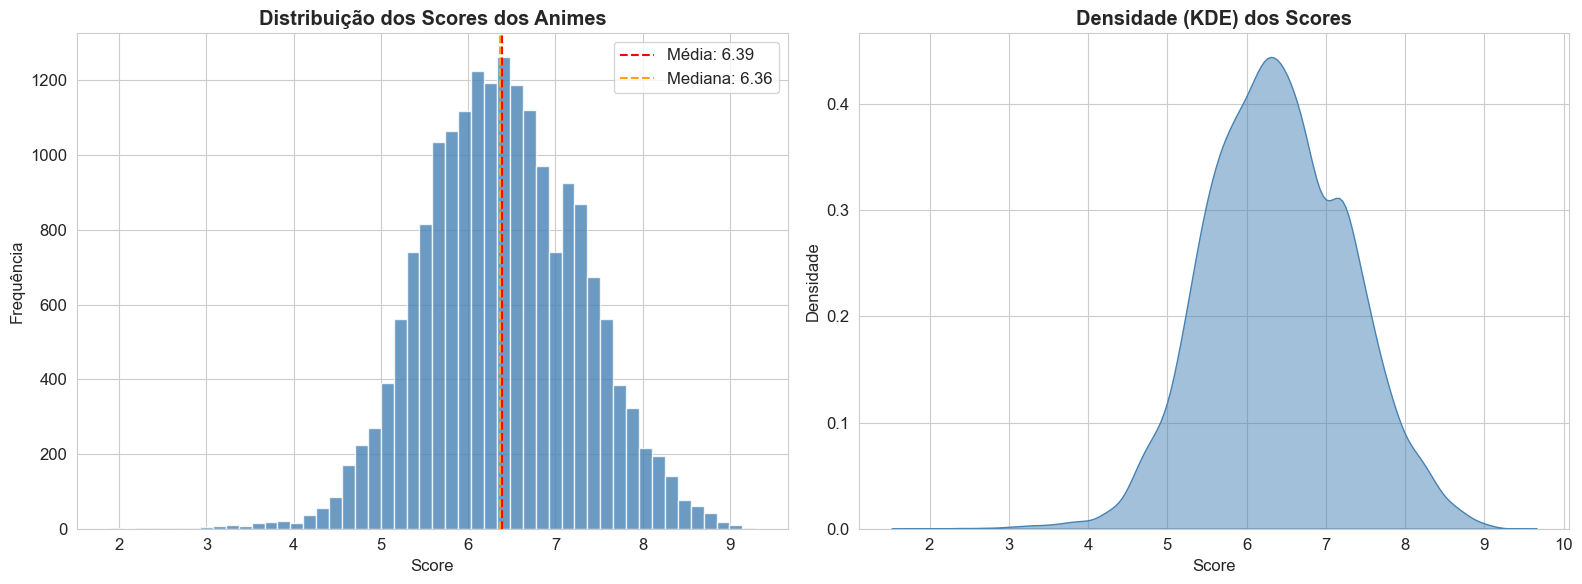

In [45]:
# Score distribution with KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(details_scored['score'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(details_scored['score'].mean(), color='red', linestyle='--', label=f"Média: {details_scored['score'].mean():.2f}")
axes[0].axvline(details_scored['score'].median(), color='orange', linestyle='--', label=f"Median: {details_scored['score'].median():.2f}")
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Anime Score Distribution', fontweight='bold')
axes[0].legend()

# KDE
sns.kdeplot(data=details_scored, x='score', fill=True, color='steelblue', alpha=0.5, ax=axes[1])
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Densidade')
axes[1].set_title('Densidade (KDE) dos Scores', fontweight='bold')

plt.tight_layout()
plt.show()

> **Insight:** The score distribution is approximately normal, centered around 6.5–7.0, with a slight left skew. Very few anime achieve extreme scores (<4 or >9), indicating a rating convergence toward the mean.

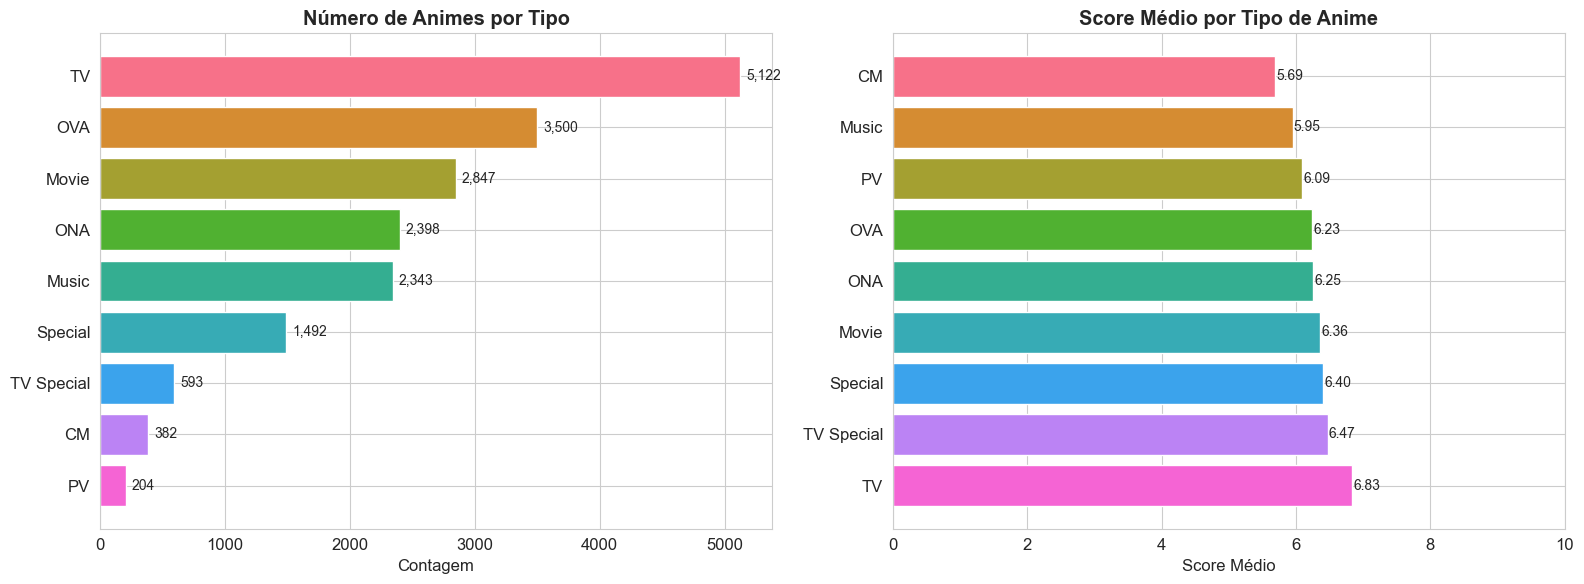

In [46]:
# Count and average score by type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_counts = details_scored['type'].value_counts()
colors = sns.color_palette('husl', len(type_counts))

axes[0].barh(type_counts.index, type_counts.values, color=colors, edgecolor='white')
for i, (v, c) in enumerate(zip(type_counts.values, type_counts.index)):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=10)
axes[0].set_xlabel('Count')
axes[0].set_title('Number of Anime por Tipo', fontweight='bold')
axes[0].invert_yaxis()

type_scores = details_scored.groupby('type')['score'].mean().sort_values(ascending=True)
axes[1].barh(type_scores.index, type_scores.values, color=colors[:len(type_scores)], edgecolor='white')
for i, v in enumerate(type_scores.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)
axes[1].set_xlabel('Score Médio')
axes[1].set_title('Score Médio por Tipo de Anime', fontweight='bold')
axes[1].set_xlim(0, 10)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

> **Insight:** TV anime dominate in count but Movies and OVAs tend to have slightly different score distributions. The type composition reveals the diversity of anime formats on MAL.

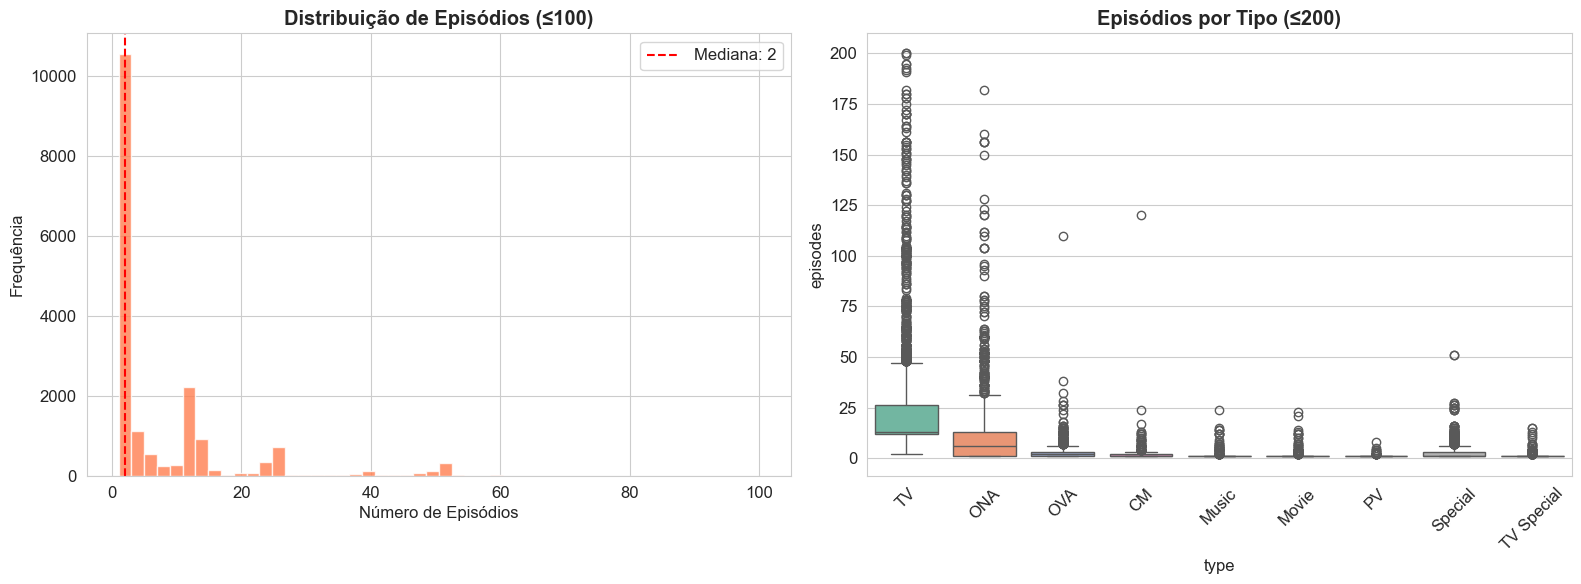

In [47]:
# Episode count distribution (truncated at 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

eps = details_scored['episodes'].dropna()
eps_filtered = eps[eps <= 100]

axes[0].hist(eps_filtered, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Número de Episódios')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Episode Distribution (≤100)', fontweight='bold')
axes[0].axvline(eps_filtered.median(), color='red', linestyle='--', label=f'Median: {eps_filtered.median():.0f}')
axes[0].legend()

# Boxplot por tipo
type_order = details_scored.groupby('type')['episodes'].median().sort_values(ascending=False).index
valid = details_scored[details_scored['episodes'] <= 200]
sns.boxplot(data=valid, x='type', y='episodes', order=type_order, palette='Set2', ax=axes[1])
axes[1].set_title('Episódios por Tipo (≤200)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Insight:** The episode distribution is heavily right-skewed — the vast majority of anime have fewer than 26 episodes (1–2 cours). Long-running series (50+ episodes) are rare outliers.

## 4.2 Category Analysis

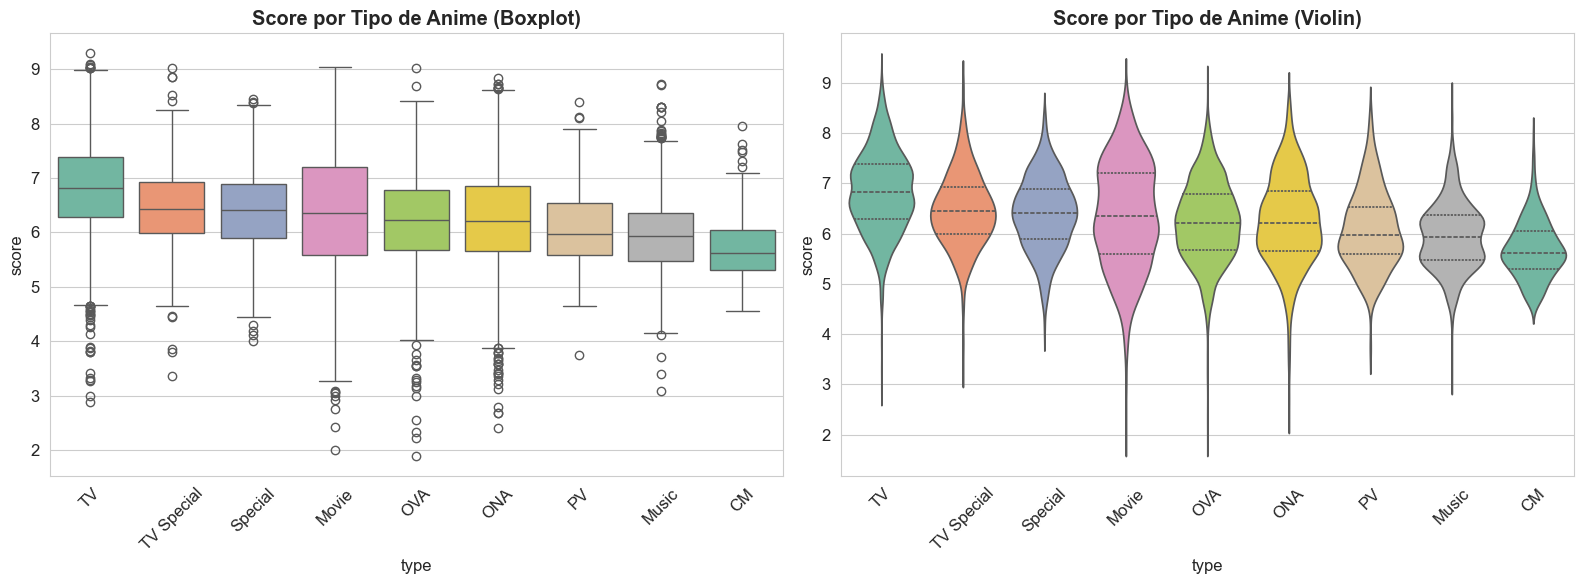

In [48]:
# Boxplot e violin plot de scores por tipo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_order = details_scored.groupby('type')['score'].median().sort_values(ascending=False).index
sns.boxplot(data=details_scored, x='type', y='score', order=type_order, palette='Set2', ax=axes[0])
axes[0].set_title('Score por Tipo de Anime (Boxplot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=details_scored, x='type', y='score', order=type_order, palette='Set2', ax=axes[1], inner='quartile')
axes[1].set_title('Score por Tipo de Anime (Violin)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> **Insight:** TV series show the widest score variance, while Movies tend to score slightly higher on average. Music and Special types cluster at lower scores with tighter distributions.

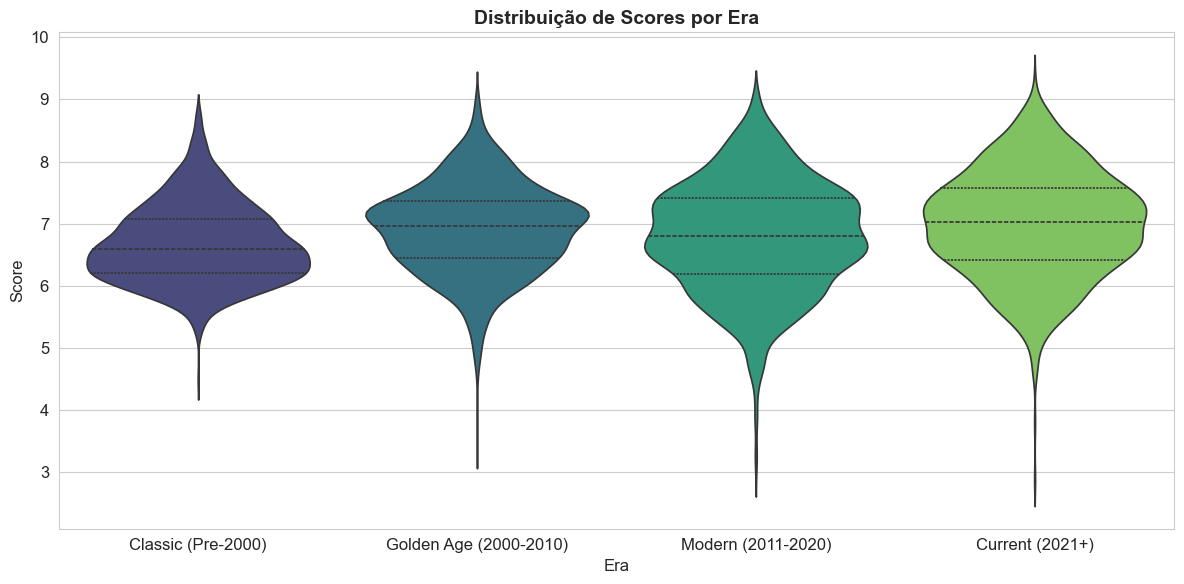

In [49]:
# Violin plot of scores by era
fig, ax = plt.subplots(figsize=(12, 6))
era_order = ['Classic (Pre-2000)', 'Golden Age (2000-2010)', 'Modern (2011-2020)', 'Current (2021+)']
valid_eras = df[df['Release_Era'].isin(era_order)]
sns.violinplot(data=valid_eras, x='Release_Era', y='score', order=era_order, palette='viridis', inner='quartile', ax=ax)
ax.set_title('Score Distribution by Era', fontweight='bold', fontsize=14)
ax.set_xlabel('Era')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

> **Insight:** Older anime eras show tighter, higher-scoring distributions (survivorship bias — only well-regarded series were added retroactively). Modern eras show much wider variance as MAL coverage became comprehensive.

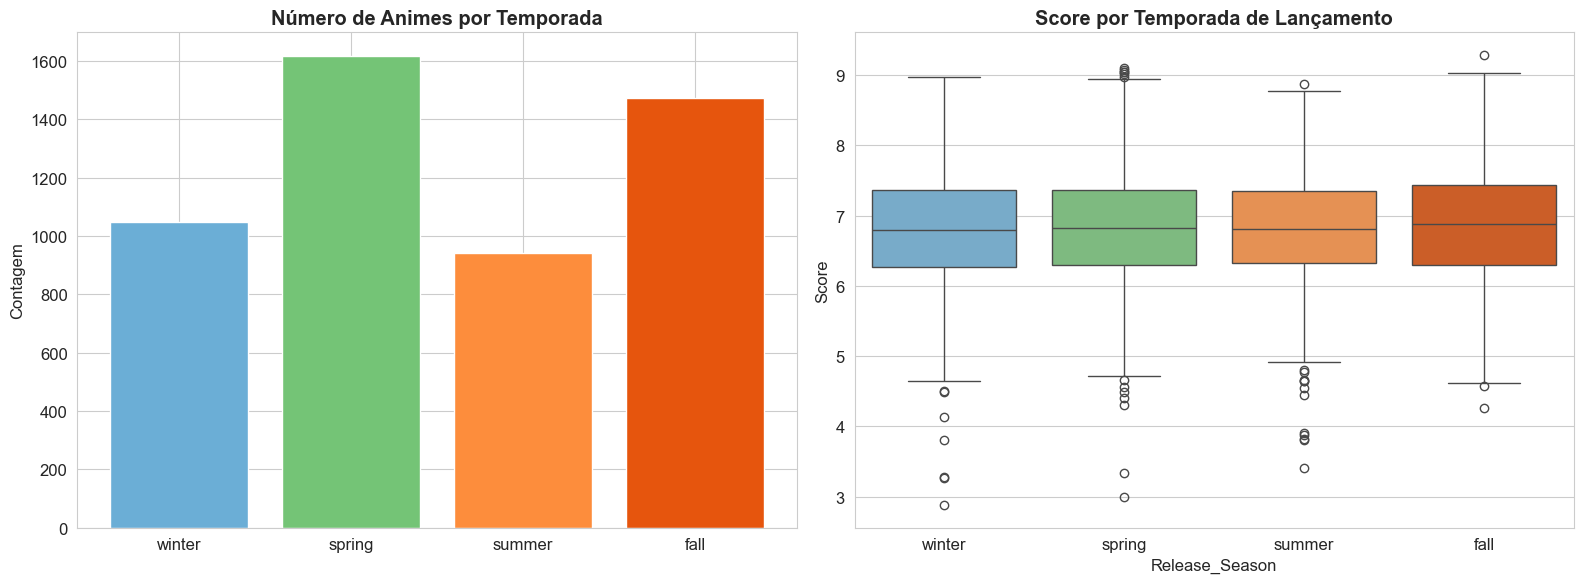

In [50]:
# Score by season
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

season_order = ['winter', 'spring', 'summer', 'fall']
valid_seasons = df[df['Release_Season'].isin(season_order)]

season_counts = valid_seasons['Release_Season'].value_counts().reindex(season_order)
axes[0].bar(season_counts.index, season_counts.values, color=['#6baed6', '#74c476', '#fd8d3c', '#e6550d'], edgecolor='white')
axes[0].set_title('Number of Anime by Season', fontweight='bold')
axes[0].set_ylabel('Count')

sns.boxplot(data=valid_seasons, x='Release_Season', y='score', order=season_order,
            palette=['#6baed6', '#74c476', '#fd8d3c', '#e6550d'], ax=axes[1])
axes[1].set_title('Score by Release Season', fontweight='bold')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

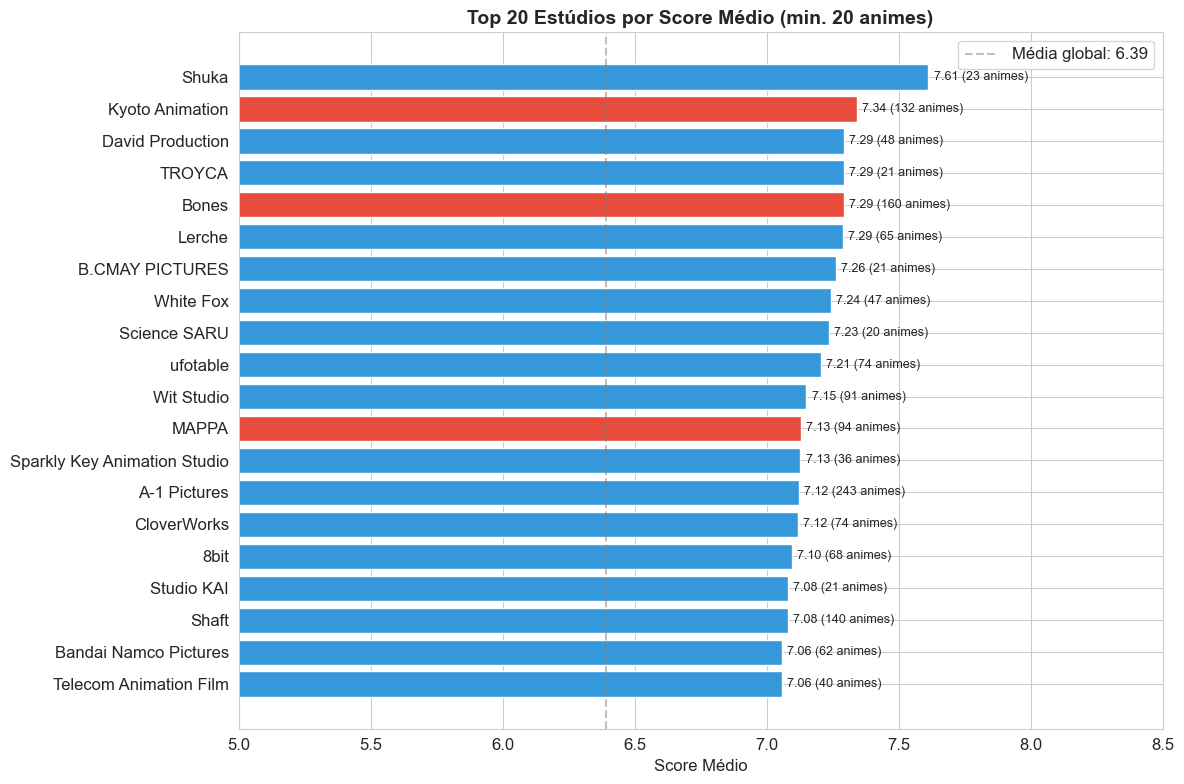

In [51]:
# Top 20 studios by average score (minimum 20 anime)
studio_stats = df.groupby('Primary_Studio').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean'),
    avg_members=('members', 'mean')
).reset_index()
studio_stats = studio_stats[studio_stats['count'] >= 20].sort_values('avg_score', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if s in ['Madhouse', 'Ufotable', 'Kyoto Animation', 'MAPPA', 'Bones', 'Studio Ghibli'] 
          else '#3498db' for s in studio_stats['Primary_Studio']]
ax.barh(studio_stats['Primary_Studio'], studio_stats['avg_score'], color=colors, edgecolor='white')
for i, (v, c) in enumerate(zip(studio_stats['avg_score'], studio_stats['count'])):
    ax.text(v + 0.02, i, f'{v:.2f} ({c} animes)', va='center', fontsize=9)
ax.set_xlabel('Score Médio')
ax.set_title('Top 20 Studios by Average Score (min. 20 anime)', fontweight='bold', fontsize=14)
ax.set_xlim(5, 8.5)
ax.axvline(df['score'].mean(), color='gray', linestyle='--', alpha=0.5, label=f'Global mean: {df["score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

> **Insight:** Top-tier studios like Studio Ghibli and Madhouse consistently produce higher-rated anime. Studios with fewer titles can appear artificially high due to smaller sample sizes.

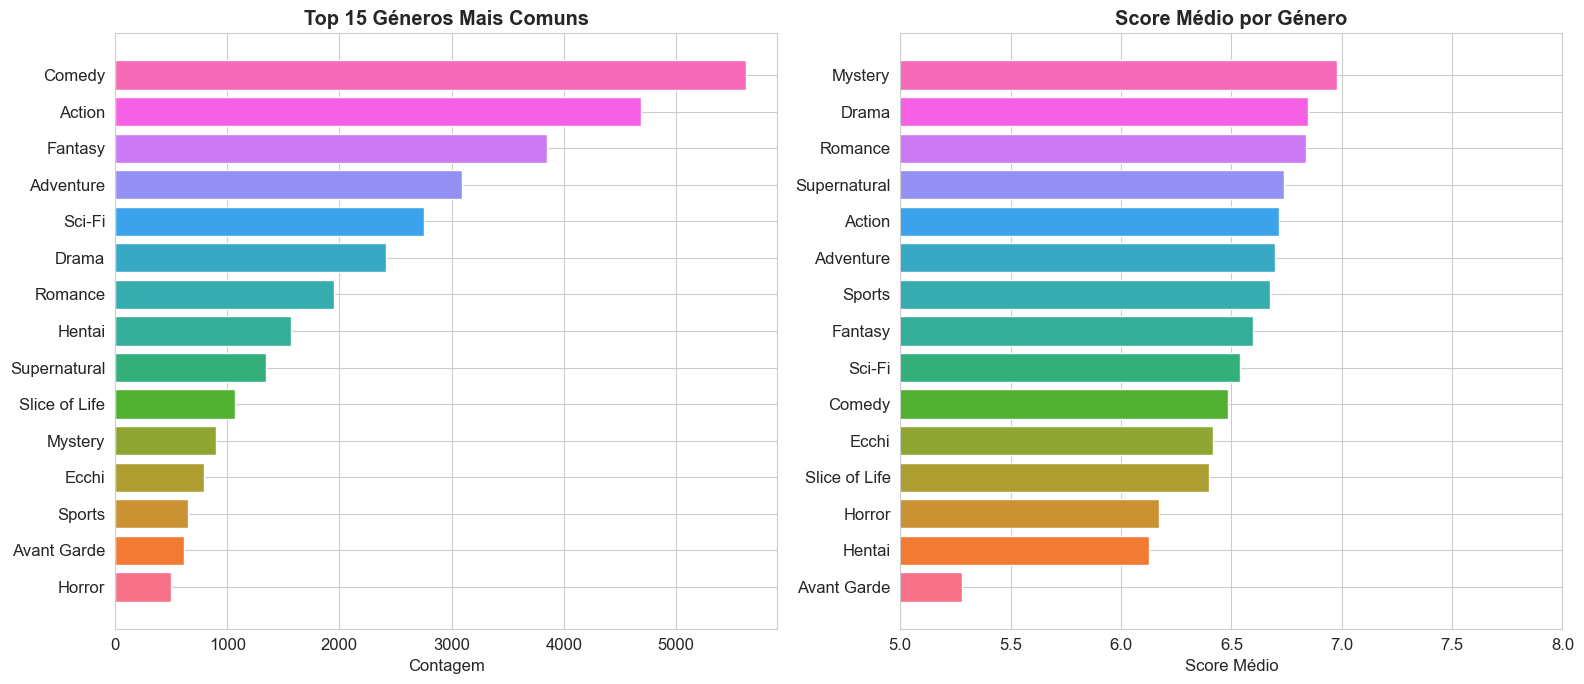

In [52]:
# Top 15 most common genres and average score
import ast as ast_mod
from collections import Counter

all_genres = []
genre_scores = {}
for _, row in df.iterrows():
    try:
        genres = ast_mod.literal_eval(row['genres']) if pd.notna(row['genres']) else []
    except:
        genres = []
    all_genres.extend(genres)
    for g in genres:
        if g not in genre_scores:
            genre_scores[g] = []
        genre_scores[g].append(row['score'])

genre_counts = Counter(all_genres)
top_genres = genre_counts.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

genres_names = [g for g, c in top_genres]
genres_vals = [c for g, c in top_genres]
colors = sns.color_palette('husl', 15)

axes[0].barh(genres_names[::-1], genres_vals[::-1], color=colors, edgecolor='white')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Most Common Genres', fontweight='bold')

avg_scores = [np.mean(genre_scores[g]) for g in genres_names]
sort_idx = np.argsort(avg_scores)
axes[1].barh([genres_names[i] for i in sort_idx], [avg_scores[i] for i in sort_idx], color=colors, edgecolor='white')
axes[1].set_xlabel('Score Médio')
axes[1].set_title('Score Médio por Género', fontweight='bold')
axes[1].set_xlim(5, 8)

plt.tight_layout()
plt.show()

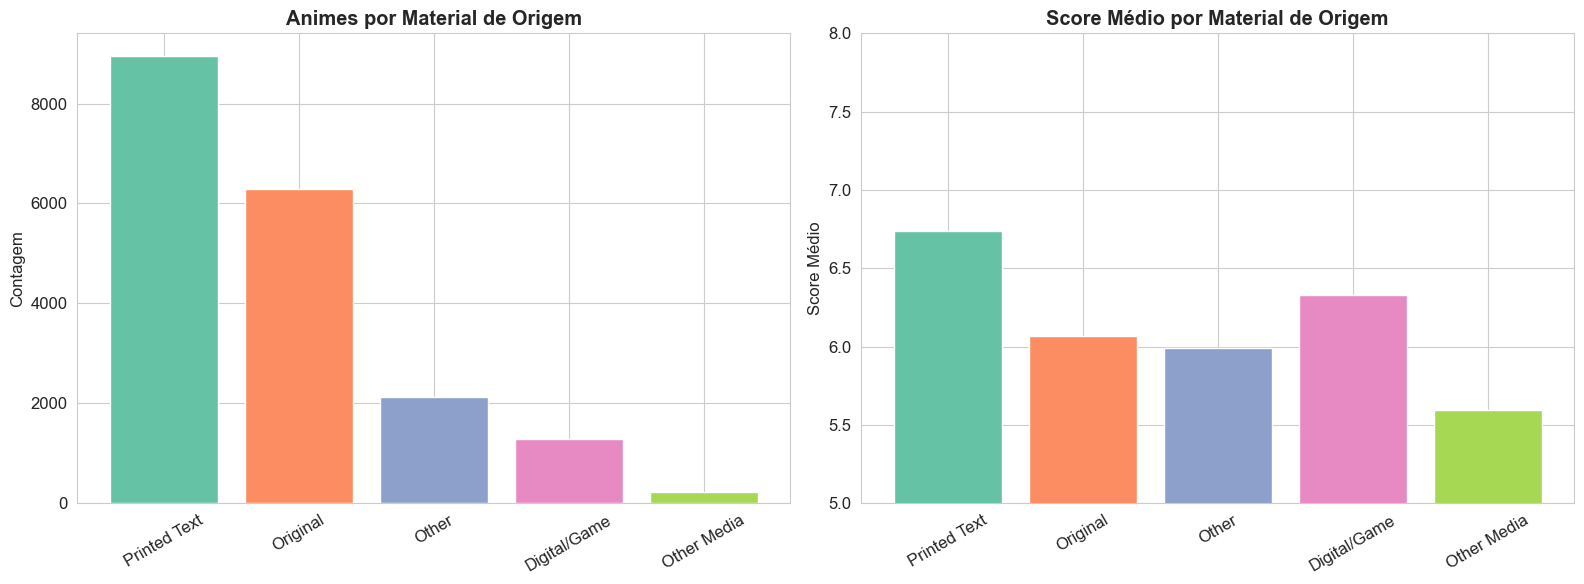

In [53]:
# Score by source material
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

source_stats = df.groupby('Source_Material_Encoded').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean')
).sort_values('count', ascending=False)

axes[0].bar(source_stats.index, source_stats['count'], color=sns.color_palette('Set2', len(source_stats)), edgecolor='white')
axes[0].set_title('Anime by Source Material', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(source_stats.index, source_stats['avg_score'], color=sns.color_palette('Set2', len(source_stats)), edgecolor='white')
axes[1].set_title('Score Médio por Material de Origem', fontweight='bold')
axes[1].set_ylabel('Score Médio')
axes[1].set_ylim(5, 8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4.3 Variable Relationships

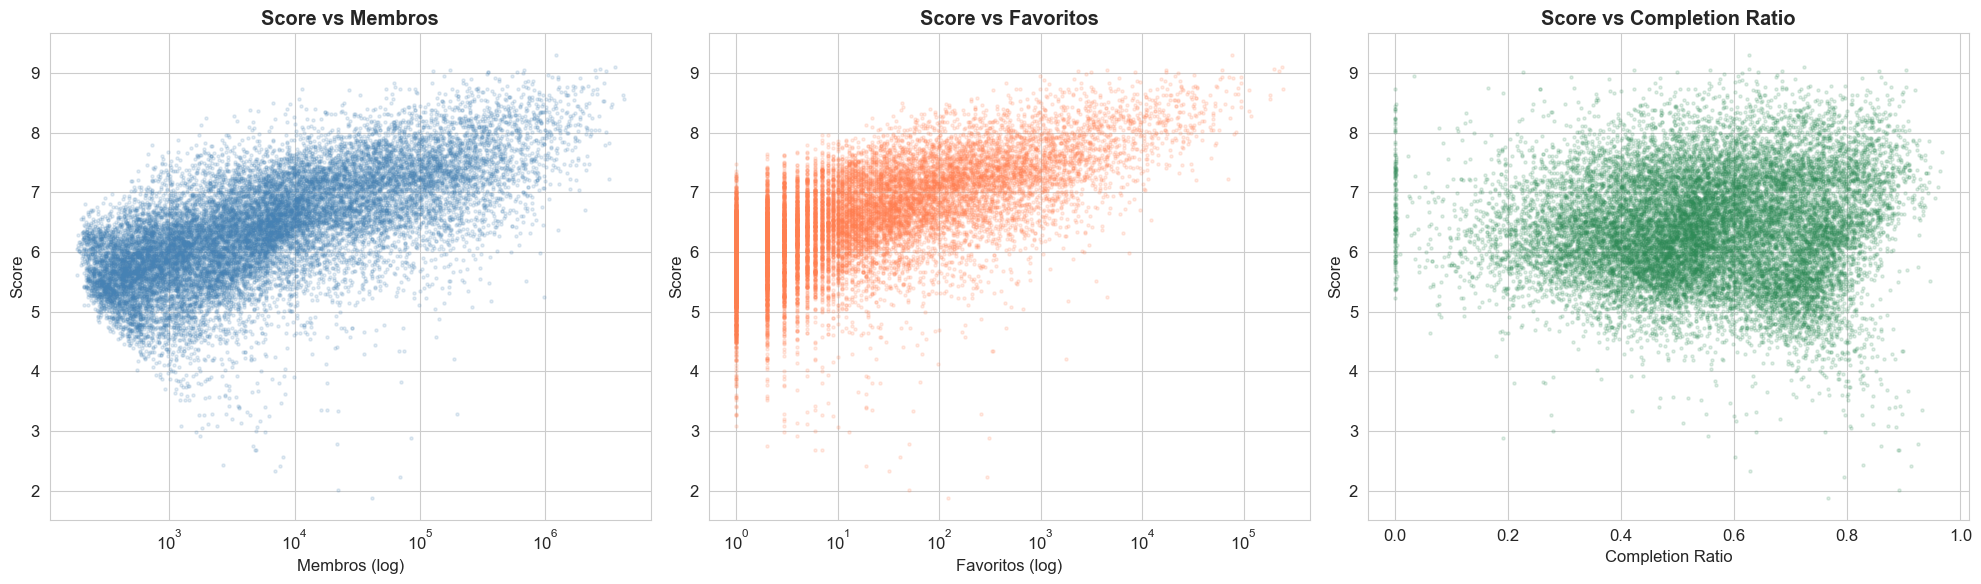

In [54]:
# Scatter plots com escala logarítmica
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Score vs Members
axes[0].scatter(df['members'], df['score'], alpha=0.15, s=5, c='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Membros (log)')
axes[0].set_ylabel('Score')
axes[0].set_title('Score vs Membros', fontweight='bold')

# Score vs Favorites
axes[1].scatter(df['favorites'], df['score'], alpha=0.15, s=5, c='coral')
axes[1].set_xscale('log')
axes[1].set_xlabel('Favoritos (log)')
axes[1].set_ylabel('Score')
axes[1].set_title('Score vs Favoritos', fontweight='bold')

# Completion_Ratio vs Score
valid = df[df['Completion_Ratio'].notna()]
axes[2].scatter(valid['Completion_Ratio'], valid['score'], alpha=0.15, s=5, c='seagreen')
axes[2].set_xlabel('Completion Ratio')
axes[2].set_ylabel('Score')
axes[2].set_title('Score vs Completion Ratio', fontweight='bold')

plt.tight_layout()
plt.show()

> **Insight:** Logarithmic scaling reveals clear positive correlations between popularity metrics (members, scored_by, favorites). Higher-scoring anime tend to attract more members, but the relationship is non-linear.

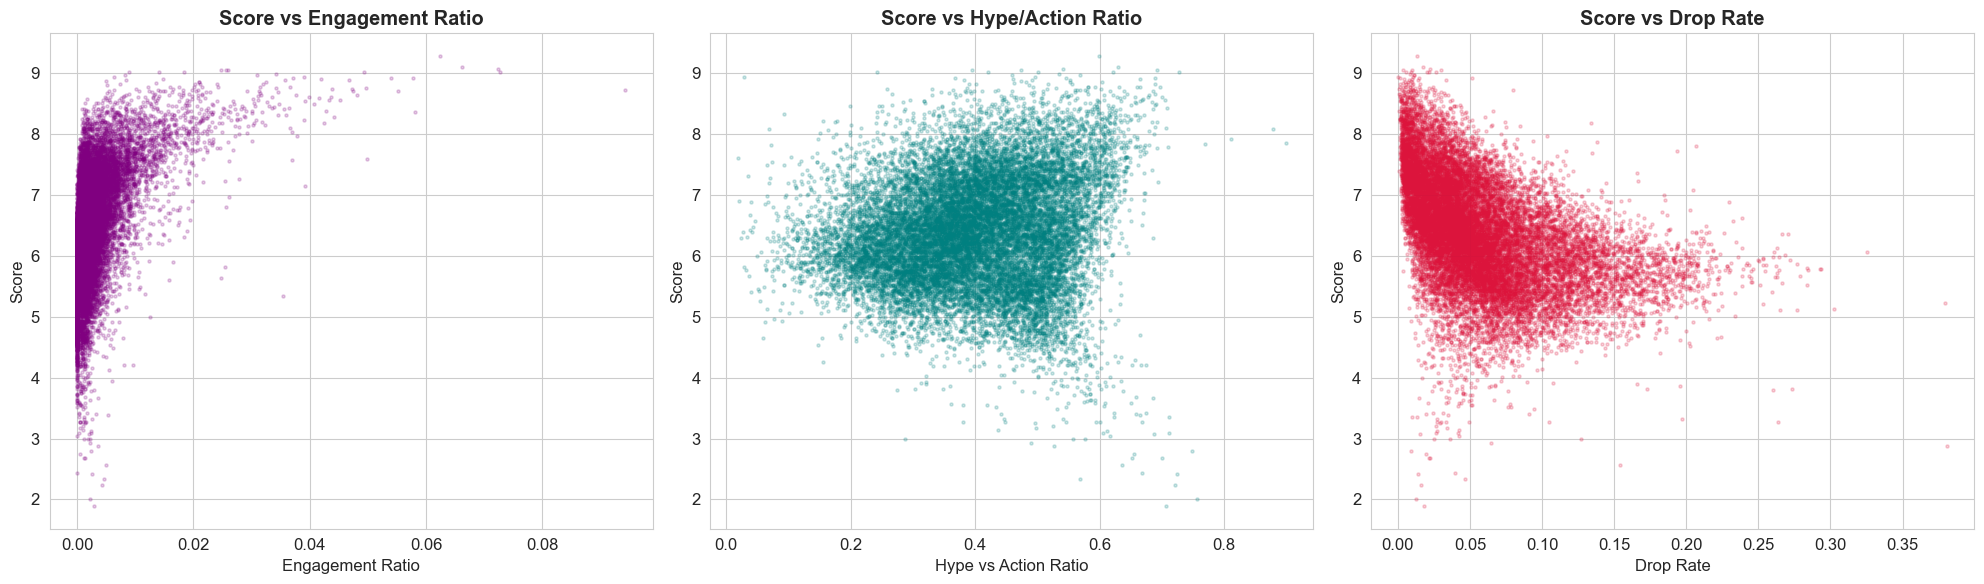

In [55]:
# Scatter: Engagement vs score, Hype vs Score
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

valid = df[df['Engagement_Ratio'].notna() & (df['members'] > 100)]
axes[0].scatter(valid['Engagement_Ratio'], valid['score'], alpha=0.2, s=5, c='purple')
axes[0].set_xlabel('Engagement Ratio')
axes[0].set_ylabel('Score')
axes[0].set_title('Score vs Engagement Ratio', fontweight='bold')

valid2 = df[df['Hype_vs_Action_Ratio'].notna() & (df['members'] > 100)]
axes[1].scatter(valid2['Hype_vs_Action_Ratio'], valid2['score'], alpha=0.2, s=5, c='teal')
axes[1].set_xlabel('Hype vs Action Ratio')
axes[1].set_ylabel('Score')
axes[1].set_title('Score vs Hype/Action Ratio', fontweight='bold')

valid3 = df[df['Drop_Rate'].notna() & (df['total'] > 100)]
axes[2].scatter(valid3['Drop_Rate'], valid3['score'], alpha=0.2, s=5, c='crimson')
axes[2].set_xlabel('Drop Rate')
axes[2].set_ylabel('Score')
axes[2].set_title('Score vs Drop Rate', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.4 Temporal Analysis

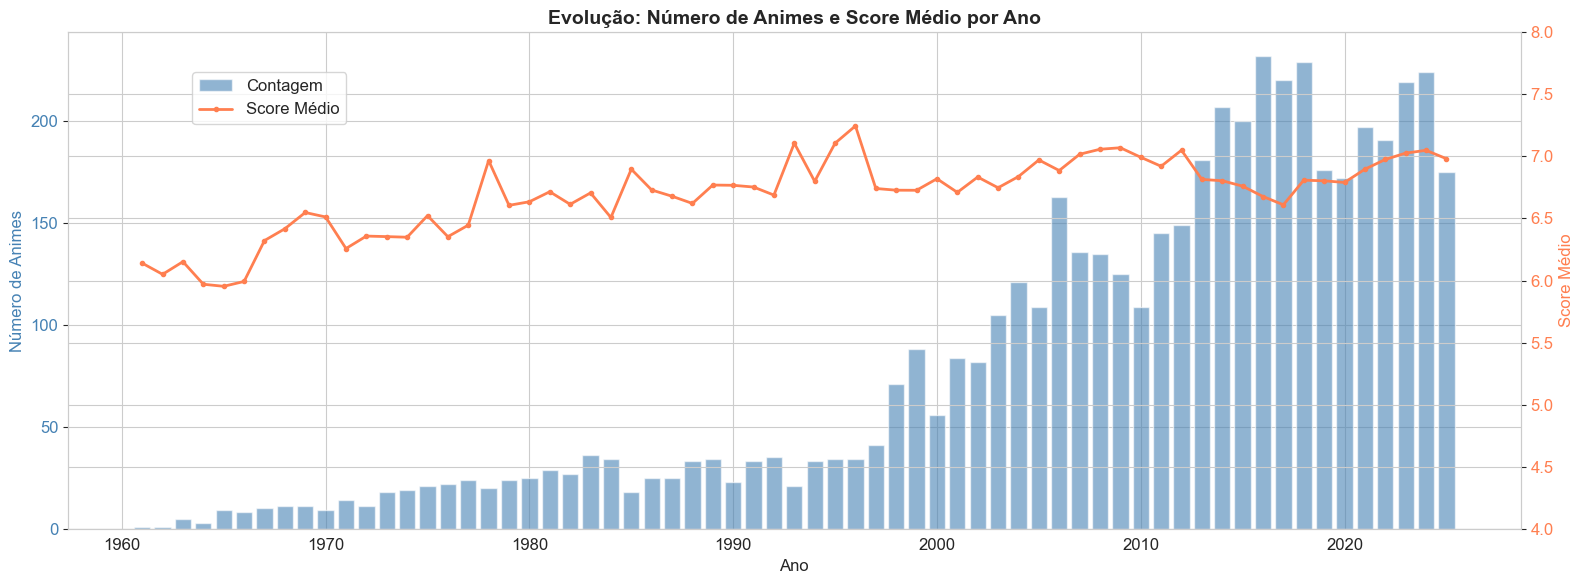

In [56]:
# Number of anime per year and average score over time
yearly = details_scored.groupby('year').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean')
).reset_index()
yearly = yearly[(yearly['year'] >= 1960) & (yearly['year'] <= 2025)]

fig, ax1 = plt.subplots(figsize=(16, 6))

color1 = 'steelblue'
color2 = 'coral'
ax1.bar(yearly['year'], yearly['count'], color=color1, alpha=0.6, label='Count')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Number of Anime', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['avg_score'], color=color2, linewidth=2, marker='o', markersize=3, label='Score Médio')
ax2.set_ylabel('Score Médio', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(4, 8)

ax1.set_title('Evolução: Number of Anime e Score Médio por Ano', fontweight='bold', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

> **Insight:** Anime production has grown exponentially since the 2000s, while average scores have remained relatively stable. The increasing volume does not correspond to a quality decline.

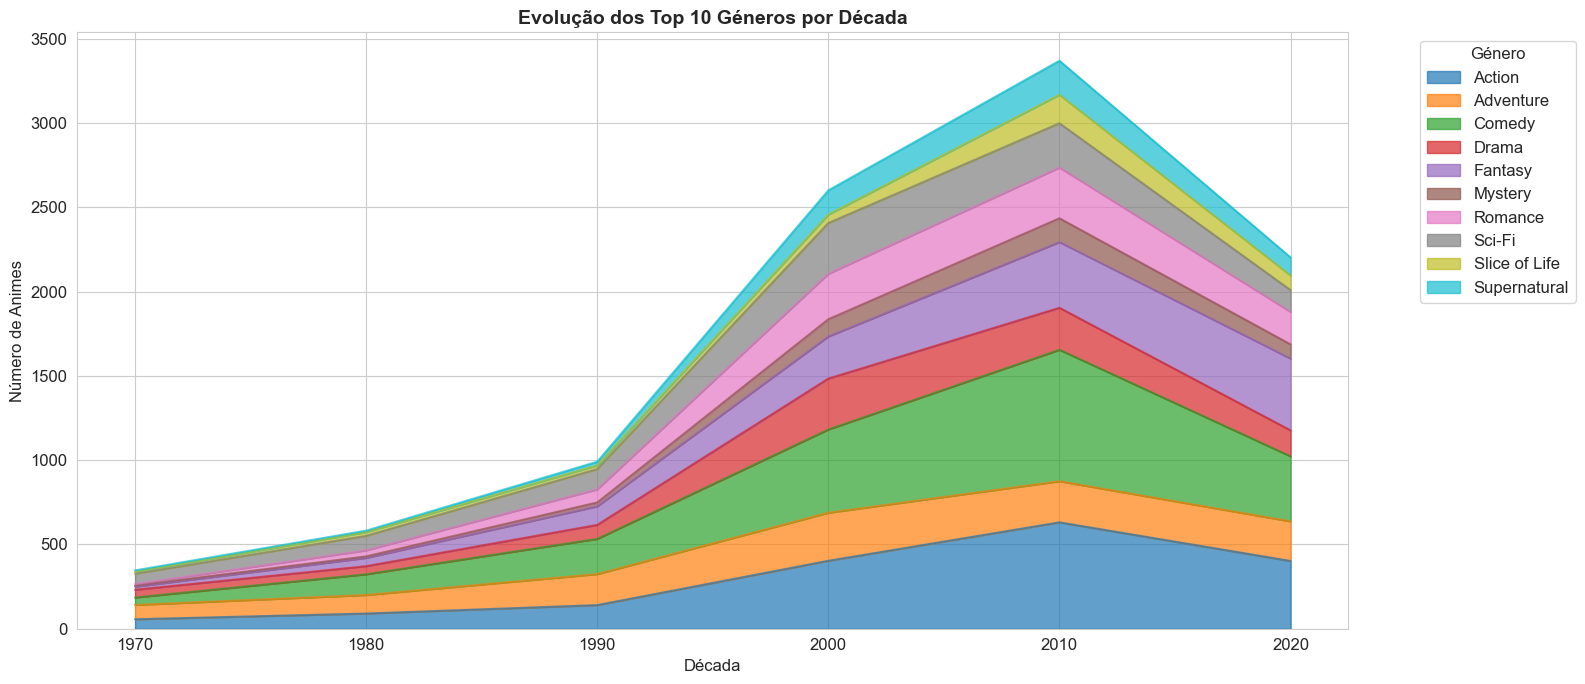

In [57]:
# Genre evolution across decades
import ast as ast_mod2

genre_year_data = []
for _, row in df.iterrows():
    if pd.notna(row['year']) and pd.notna(row['genres']):
        try:
            genres = ast_mod2.literal_eval(row['genres'])
        except:
            genres = []
        decade = int(row['year'] // 10 * 10)
        if decade >= 1970:
            for g in genres:
                genre_year_data.append({'decade': decade, 'genre': g})

genre_year_df = pd.DataFrame(genre_year_data)
top_10_genres = genre_year_df['genre'].value_counts().head(10).index.tolist()
genre_year_filtered = genre_year_df[genre_year_df['genre'].isin(top_10_genres)]

pivot = genre_year_filtered.groupby(['decade', 'genre']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
pivot.plot(kind='area', stacked=True, alpha=0.7, ax=ax, colormap='tab10')
ax.set_xlabel('Década')
ax.set_ylabel('Number of Anime')
ax.set_title('Evolution of Top 10 Genres by Decade', fontweight='bold', fontsize=14)
ax.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

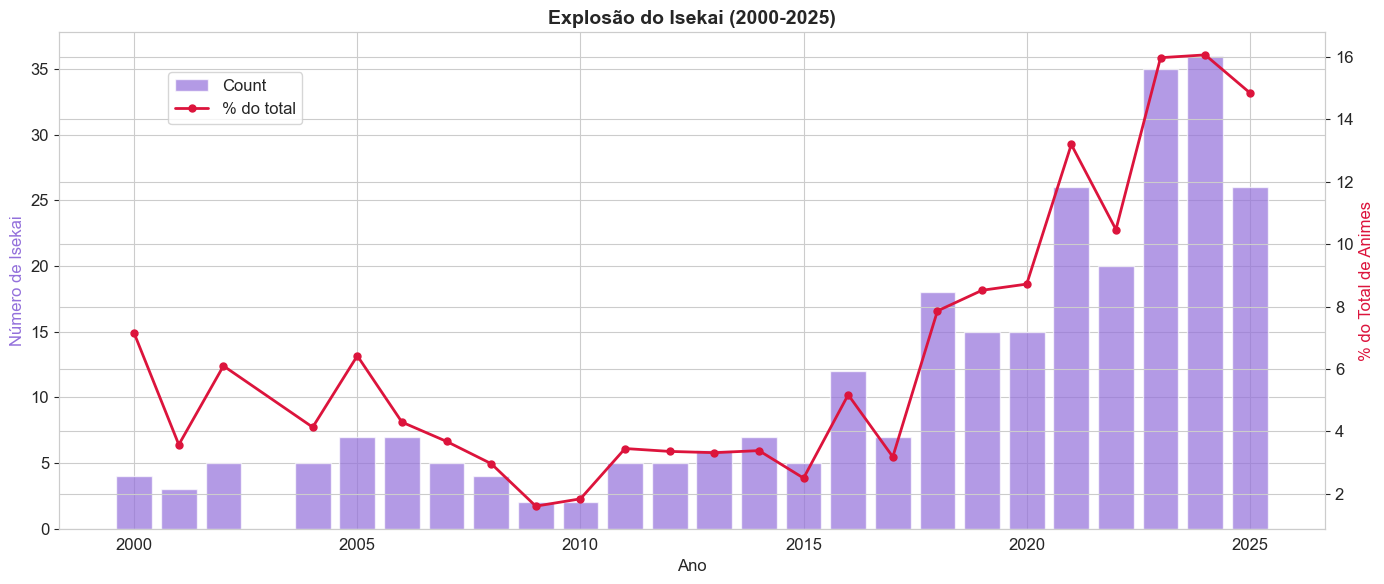

In [58]:
# Growth of Isekai over the years
isekai_by_year = df[df['Is_Isekai_Flag'] == 1].groupby('year').size().reset_index(name='count')
isekai_by_year = isekai_by_year[(isekai_by_year['year'] >= 2000) & (isekai_by_year['year'] <= 2025)]

total_by_year = df.groupby('year').size().reset_index(name='total')
isekai_pct = isekai_by_year.merge(total_by_year, on='year')
isekai_pct['pct'] = isekai_pct['count'] / isekai_pct['total'] * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(isekai_pct['year'], isekai_pct['count'], color='mediumpurple', alpha=0.7, label='Count')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Número de Isekai', color='mediumpurple')

ax2 = ax1.twinx()
ax2.plot(isekai_pct['year'], isekai_pct['pct'], color='crimson', linewidth=2, marker='o', markersize=5, label='% do total')
ax2.set_ylabel('% do Total de Animes', color='crimson')

ax1.set_title('Explosão do Isekai (2000-2025)', fontweight='bold', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

> **Insight:** The Isekai genre experienced explosive growth starting around 2015, reflecting a broader industry trend. Despite the surge in quantity, scores for Isekai titles vary widely.

## 4.5 Visualizations of Created Features

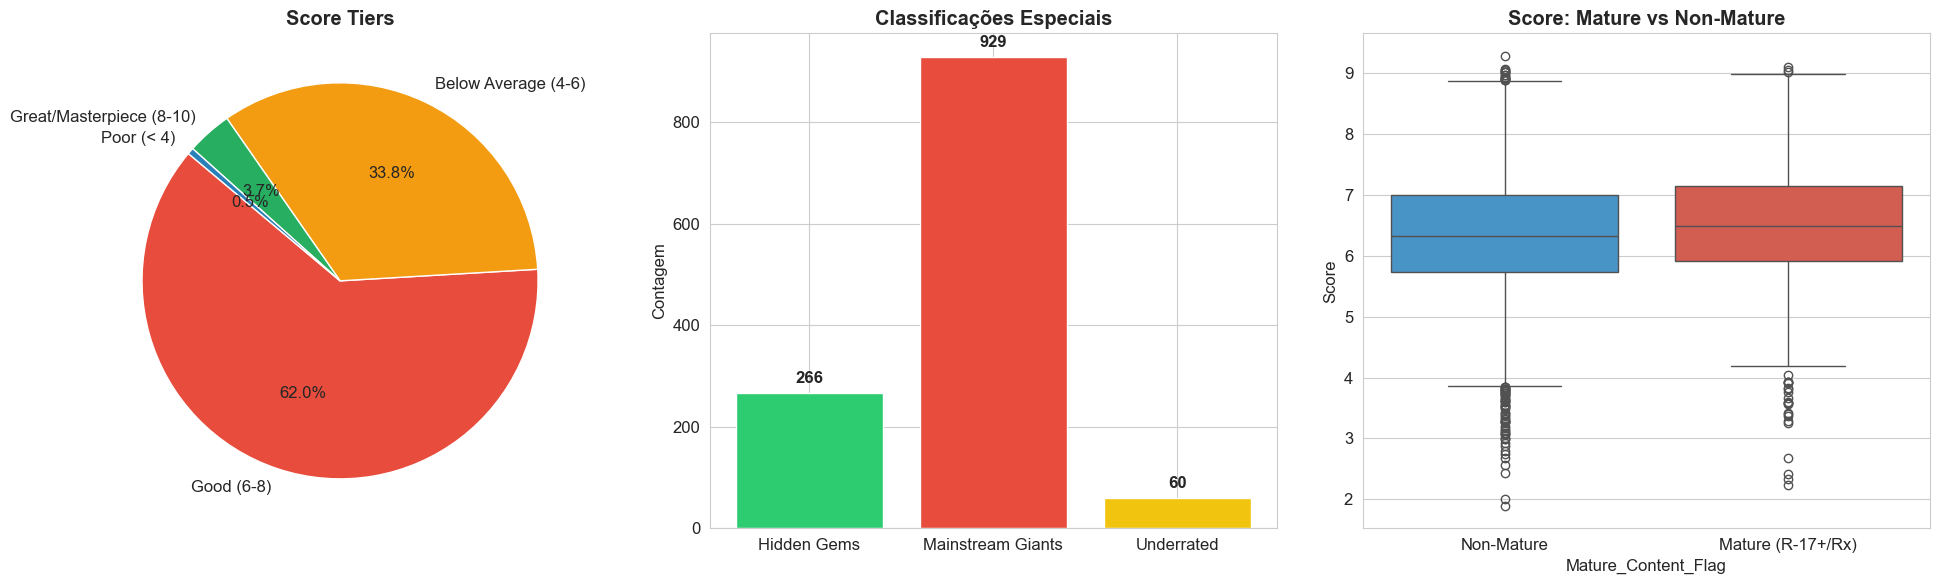

In [59]:
# Score Tier pie + Hidden Gems vs Mainstream
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Pie chart - Score Tier
tier_counts = df['Score_Tier'].value_counts()
colors_pie = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']
axes[0].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=colors_pie, startangle=140)
axes[0].set_title('Score Tiers', fontweight='bold')

# Bar - Hidden Gem vs Mainstream Giant vs Underrated
flag_counts = {
    'Hidden Gems': df['Hidden_Gem_Flag'].sum(),
    'Mainstream Giants': df['Mainstream_Giant_Flag'].sum(),
    'Underrated': df['Underrated_Flag'].sum(),
}
axes[1].bar(flag_counts.keys(), flag_counts.values(), color=['#2ecc71', '#e74c3c', '#f1c40f'], edgecolor='white')
axes[1].set_title('Classificações Especiais', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(flag_counts.values()):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Boxplot - Mature vs Non-Mature scores
sns.boxplot(data=df, x='Mature_Content_Flag', y='score', palette=['#3498db', '#e74c3c'], ax=axes[2])
axes[2].set_xticklabels(['Non-Mature', 'Mature (R-17+/Rx)'])
axes[2].set_title('Score: Mature vs Non-Mature', fontweight='bold')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show()

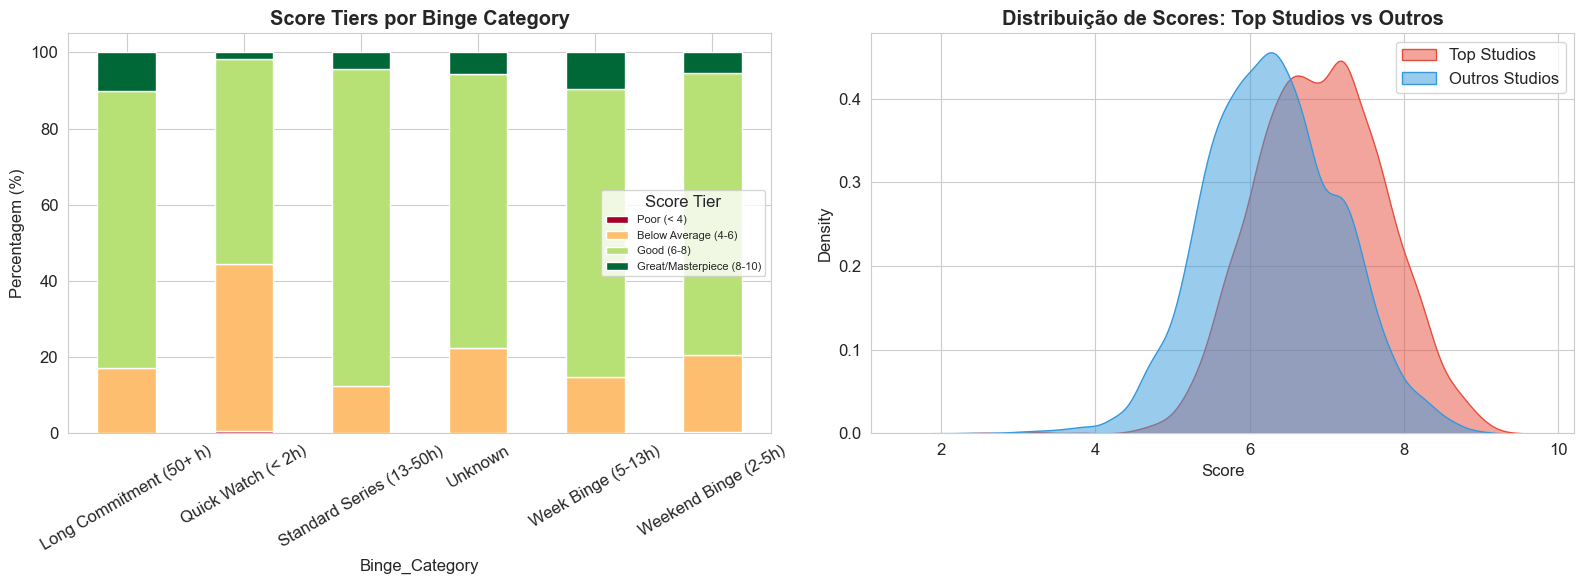

In [60]:
# Binge Category vs Score Tier (stacked bar)
binge_tier = pd.crosstab(df['Binge_Category'], df['Score_Tier'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

binge_tier.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn', edgecolor='white')
axes[0].set_title('Score Tiers por Binge Category', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Score Tier', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

# Top/Bottom Studio comparison
top_studio_scores = df[df['Top_Tier_Studio_Flag']==1]['score']
other_studio_scores = df[df['Top_Tier_Studio_Flag']==0]['score']
sns.kdeplot(top_studio_scores, fill=True, alpha=0.5, label='Top Studios', color='#e74c3c', ax=axes[1])
sns.kdeplot(other_studio_scores, fill=True, alpha=0.5, label='Outros Studios', color='#3498db', ax=axes[1])
axes[1].set_title('Score Distribution: Top Studios vs Others', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

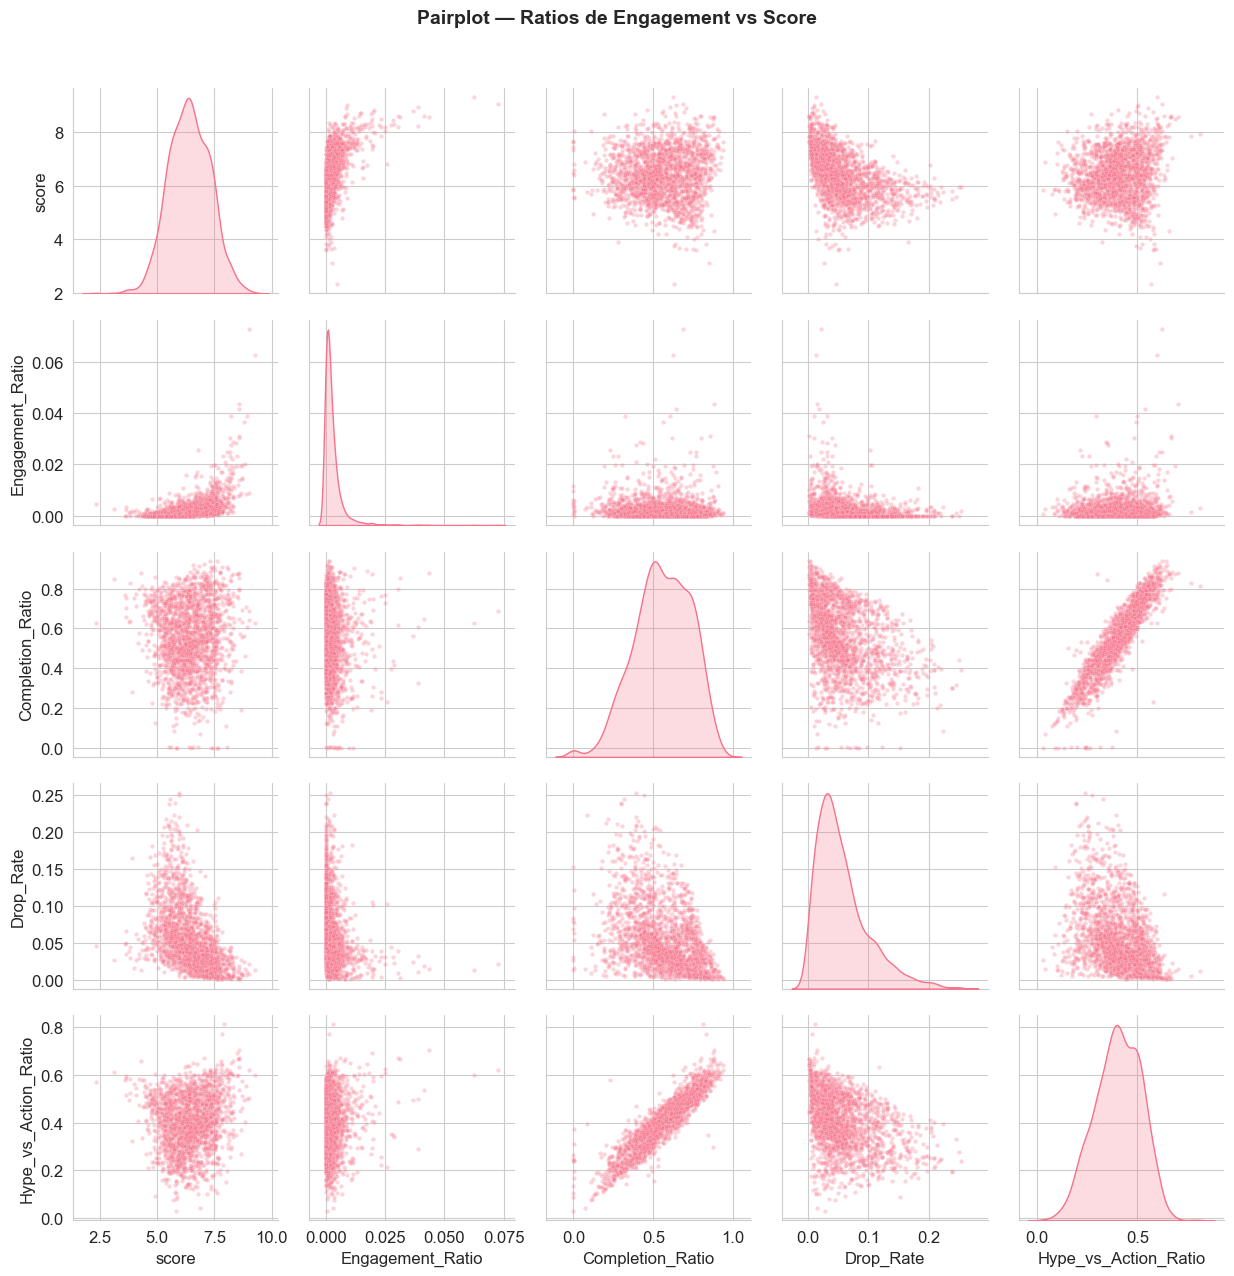

In [61]:
# Pairplot of main variables (sample)
sample = df.sample(min(2000, len(df)), random_state=42)
pair_vars = ['score', 'Engagement_Ratio', 'Completion_Ratio', 'Drop_Rate', 'Hype_vs_Action_Ratio']
g = sns.pairplot(sample[pair_vars].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10}, height=2.5)
g.fig.suptitle('Pairplot — Ratios de Engagement vs Score', y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


[⬆ Back to Index](#-table-of-contents)

---

---
# 5. Normalization and Standardization

In this section we apply two transformation methods to numerical data and compare distributions:

- **Min-Max Normalization**: transforms to the [0, 1] range
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

- **Z-Score Standardization**: transforms to mean 0 and standard deviation 1
$$X_{std} = \frac{X - \mu}{\sigma}$$

In [62]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Numerical variables to transform
norm_cols = ['score', 'scored_by', 'members', 'favorites', 'episodes',
             'Engagement_Ratio', 'Completion_Ratio', 'Drop_Rate', 
             'Hype_vs_Action_Ratio', 'Genre_Count']

# Cleaned data (no NaN in selected columns)
df_clean = df[norm_cols].dropna().copy()
print(f"Records with complete data for comp.: {len(df_clean):,}")

# Min-Max Normalização
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_clean), columns=[c + '_minmax' for c in norm_cols], index=df_clean.index)

# Z-Score Standardização
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(scaler_zscore.fit_transform(df_clean), columns=[c + '_zscore' for c in norm_cols], index=df_clean.index)

print("\n=== Statistics After Min-Max Normalization ===\n")
print(df_minmax.describe().round(4).to_string())

print("\n\n=== Statistics After Z-Score Standardization ===\n")
print(df_zscore.describe().round(4).to_string())

Registos com dados completos para normalização: 18,761

=== Estatísticas Após Min-Max Normalização ===

       score_minmax  scored_by_minmax  members_minmax  favorites_minmax  episodes_minmax  Engagement_Ratio_minmax  Completion_Ratio_minmax  Drop_Rate_minmax  Hype_vs_Action_Ratio_minmax  Genre_Count_minmax
count      18761.00          18761.00        18761.00          18761.00         18761.00                 18761.00                 18761.00          18761.00                     18761.00            18761.00
mean           0.61              0.01            0.01              0.00             0.00                     0.04                     0.57              0.15                         0.43                0.25
std            0.12              0.04            0.05              0.02             0.02                     0.06                     0.18              0.12                         0.13                0.17
min            0.00              0.00            0.00              0.00 

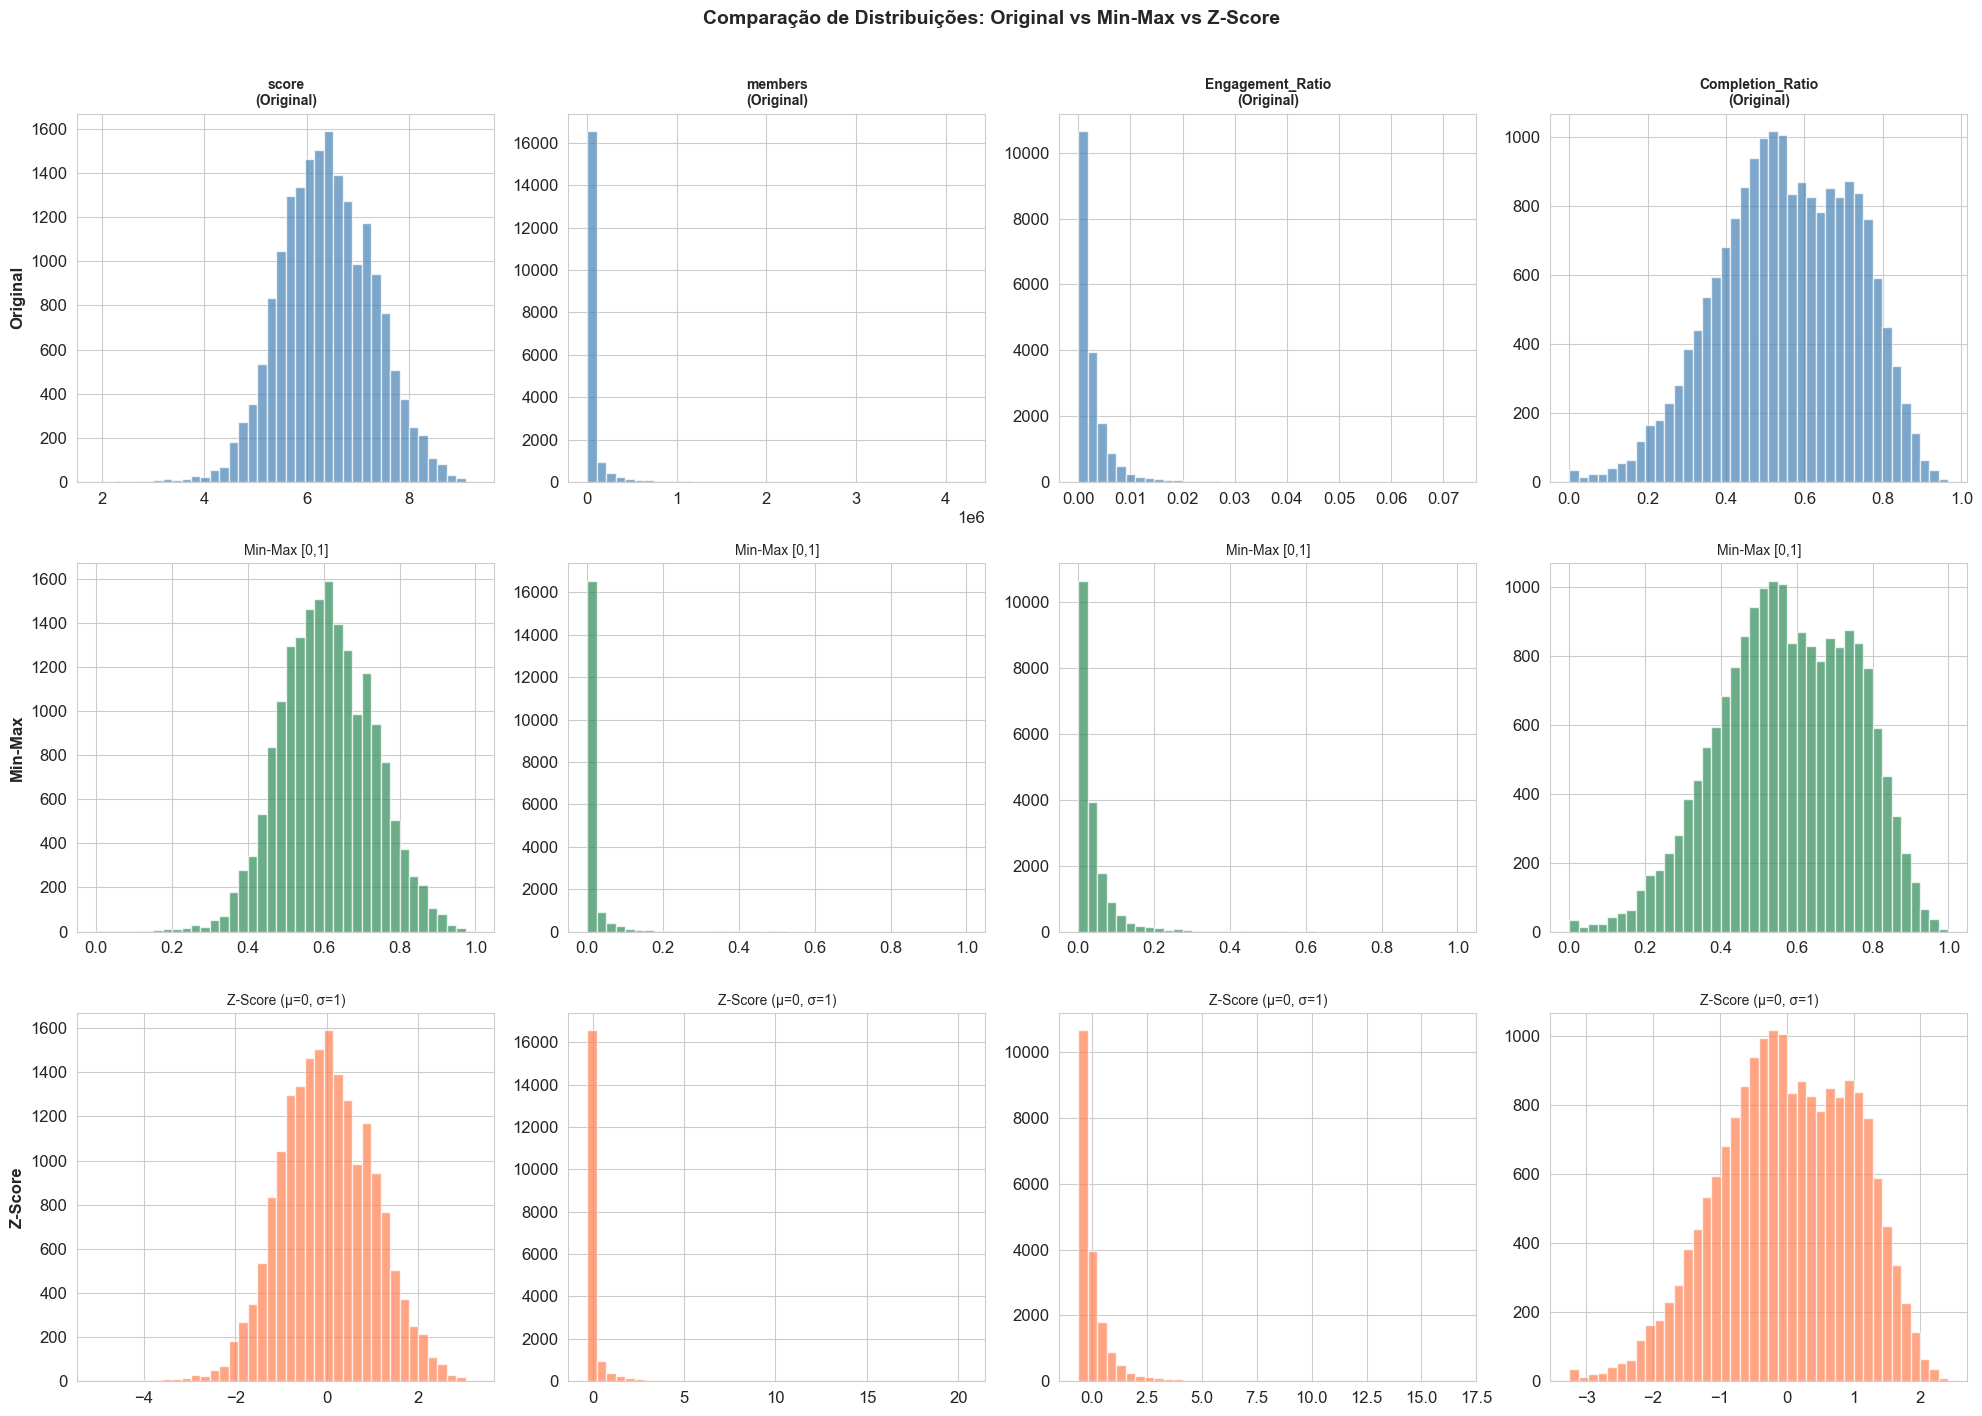

In [63]:
# Visual comparison: Original vs Min-Max vs Z-Score
fig, axes = plt.subplots(3, 4, figsize=(20, 14))

compare_cols = ['score', 'members', 'Engagement_Ratio', 'Completion_Ratio']

for j, col in enumerate(compare_cols):
    # Original
    axes[0, j].hist(df_clean[col], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0, j].set_title(f'{col}\n(Original)', fontweight='bold', fontsize=10)
    
    # Min-Max
    axes[1, j].hist(df_minmax[col + '_minmax'], bins=40, color='seagreen', alpha=0.7, edgecolor='white')
    axes[1, j].set_title(f'Min-Max [0,1]', fontsize=10)
    
    # Z-Score
    axes[2, j].hist(df_zscore[col + '_zscore'], bins=40, color='coral', alpha=0.7, edgecolor='white')
    axes[2, j].set_title(f'Z-Score (μ=0, σ=1)', fontsize=10)

axes[0, 0].set_ylabel('Original', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Min-Max', fontweight='bold', fontsize=12)
axes[2, 0].set_ylabel('Z-Score', fontweight='bold', fontsize=12)

fig.suptitle('Distribution Comparison: Original vs Min-Max vs Z-Score', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Insight:** Min-Max normalization compresses outliers, while Z-Score standardization better preserves the shape of the original distribution. Highly skewed variables (members, favorites) remain skewed under both transformations.

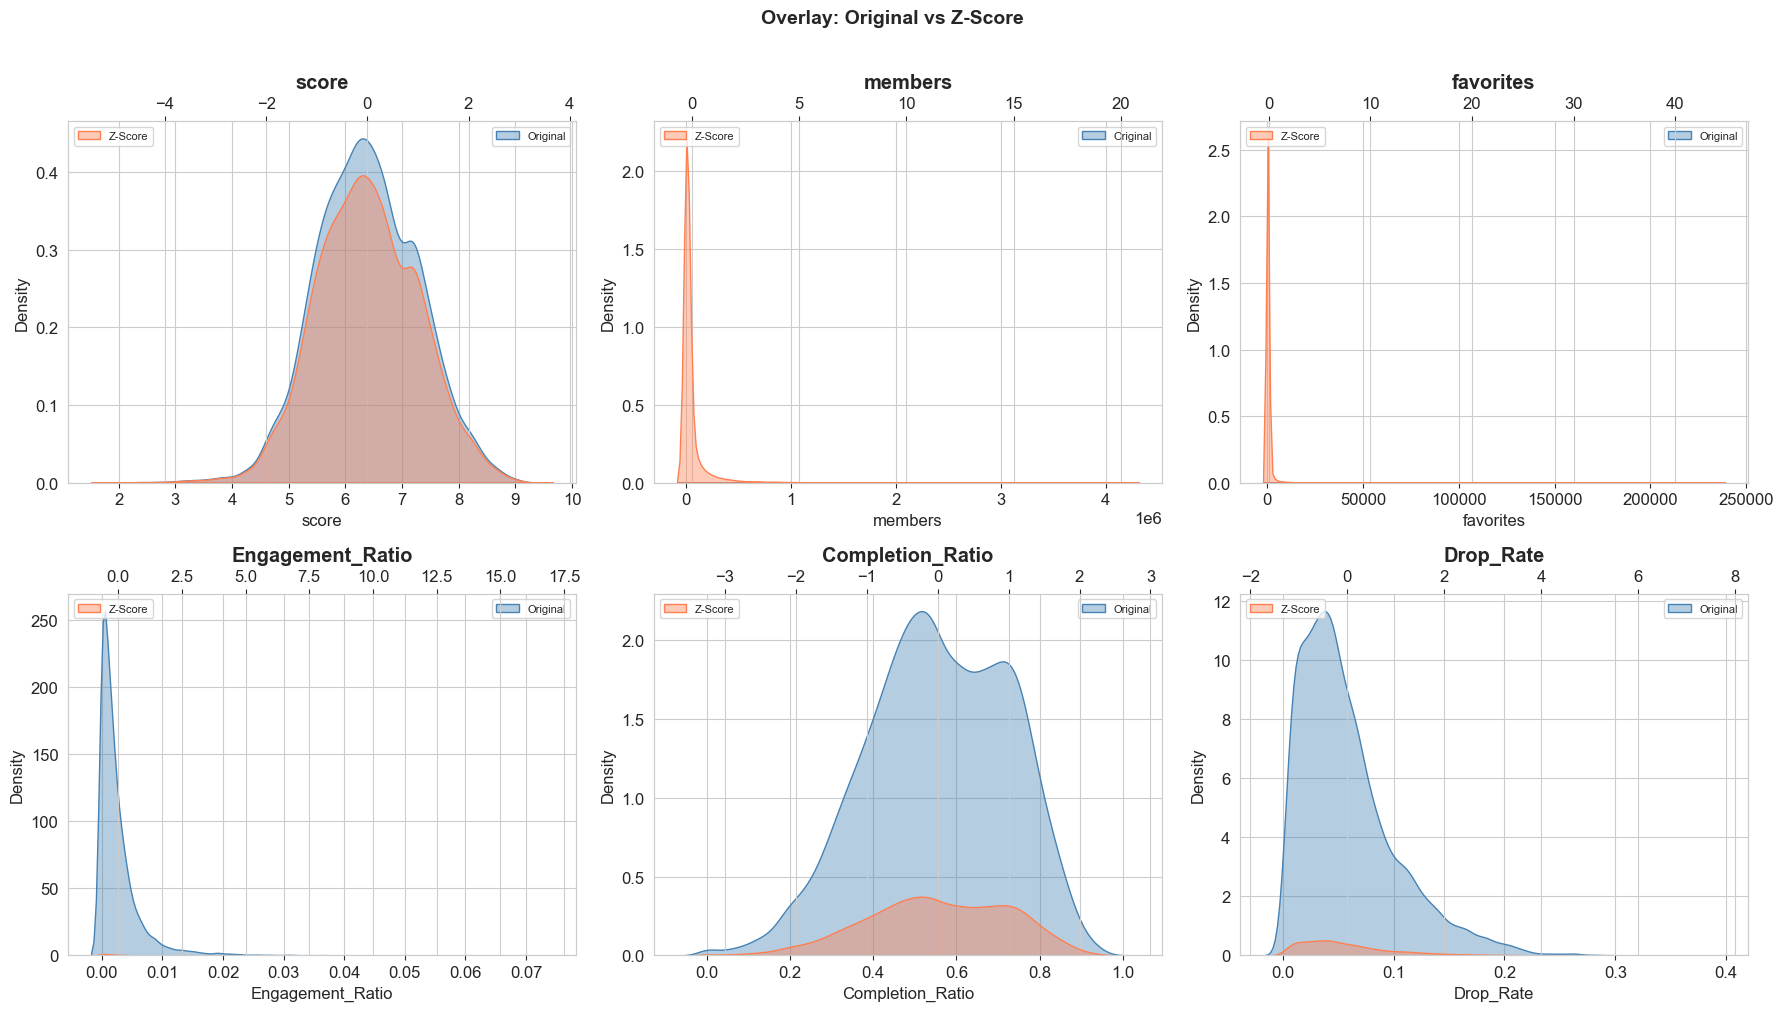

In [64]:
# KDE overlay to compare distribution shapes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
overlay_cols = ['score', 'members', 'favorites', 'Engagement_Ratio', 'Completion_Ratio', 'Drop_Rate']

for idx, col in enumerate(overlay_cols):
    ax = axes[idx // 3, idx % 3]
    
    # Z-Score is most useful for comparing shapes
    data_orig = df_clean[col]
    data_zscore = df_zscore[col + '_zscore']
    
    sns.kdeplot(data_orig, fill=True, alpha=0.4, label='Original', color='steelblue', ax=ax)
    ax_twin = ax.twiny()
    sns.kdeplot(data_zscore, fill=True, alpha=0.4, label='Z-Score', color='coral', ax=ax_twin)
    
    ax.set_title(f'{col}', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax_twin.legend(loc='upper left', fontsize=8)
    ax_twin.set_xlabel('')

fig.suptitle('Overlay: Original vs Z-Score', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Transformation Analysis

**Min-Max Normalization:**
- Transforms all values to the [0, 1] range
- Preserves the original distribution shape
- Sensitive to outliers (extreme values compress the majority of data near 0)
- Useful for: neural networks, distance-based algorithms (KNN, K-Means)

**Z-Score Standardization:**
- Centers data at the mean (μ=0) with unit standard deviation (σ=1)
- Preserves outliers but makes distributions comparable
- More robust for data with outliers
- Useful for: linear regression, PCA, SVM

**Key Observations:**
- Variables like `members` and `favorites` are highly skewed — even after normalization/standardization, the shape remains skewed
- For these variables, a prior logarithmic transformation could be beneficial
- `score` has an approximately normal distribution, so both transformations work well

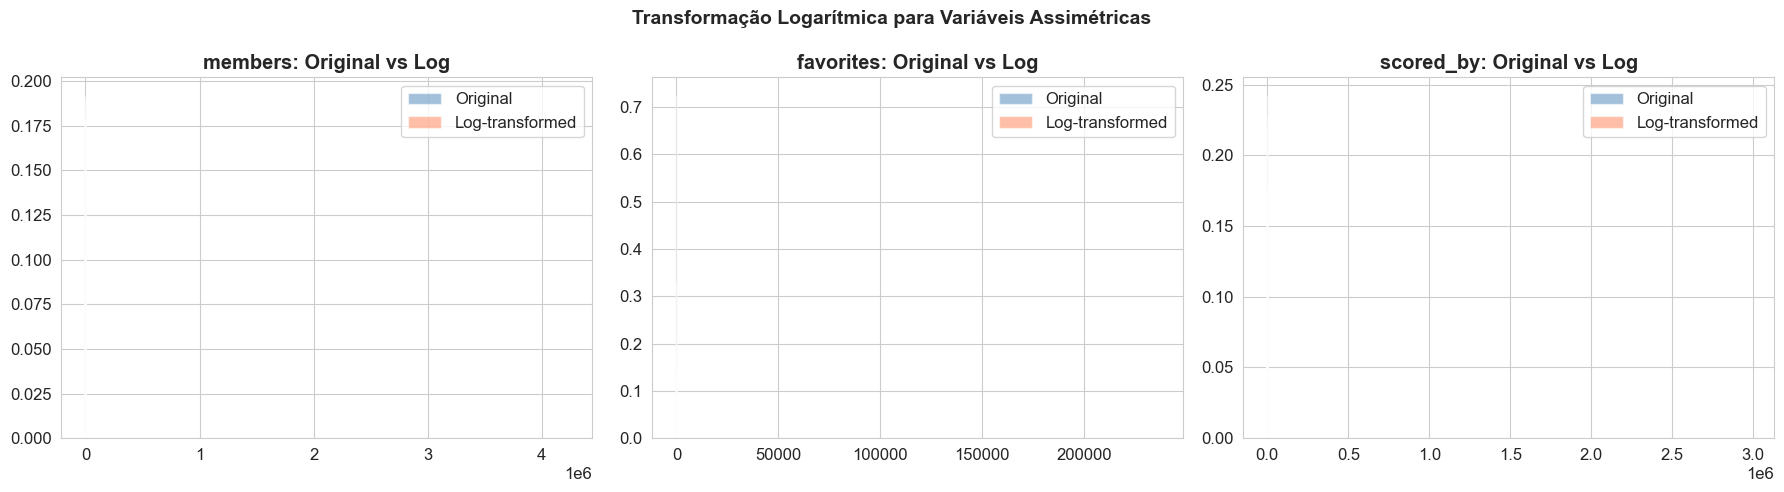


=== Skewness Antes e Depois de Log ===
  members        : Original skew = 7.98 -> Log skew = 0.53
  favorites      : Original skew = 22.54 -> Log skew = 0.95
  scored_by      : Original skew = 9.74 -> Log skew = 0.63


In [65]:
# Analysis with prior log transformation for skewed variables
log_cols = ['members', 'favorites', 'scored_by']
df_log = df_clean.copy()
for col in log_cols:
    df_log[col] = np.log1p(df_log[col])

# Z-Score após log
scaler_log = StandardScaler()
df_log_zscore = pd.DataFrame(scaler_log.fit_transform(df_log), columns=[c + '_log_zscore' for c in norm_cols], index=df_log.index)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(log_cols):
    axes[idx].hist(df_clean[col], bins=40, alpha=0.5, color='steelblue', label='Original', density=True)
    axes[idx].hist(df_log[col], bins=40, alpha=0.5, color='coral', label='Log-transformed', density=True)
    axes[idx].set_title(f'{col}: Original vs Log', fontweight='bold')
    axes[idx].legend()

fig.suptitle('Logarithmic Transformation for Skewed Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== Skewness Before and After Log ===")
for col in log_cols:
    orig_skew = df_clean[col].skew()
    log_skew = df_log[col].skew()
    print(f"  {col:15s}: Original skew = {orig_skew:.2f} -> Log skew = {log_skew:.2f}")


[⬆ Back to Index](#-table-of-contents)

---

---
# 6. Critical Analysis

In this section we critically analyze the data, identifying limitations, biases, and discussing quality/representativeness.

## 6.1 Data Quality

### Missing Values
One of the first limitations observed is the significant presence of null values across several columns.

In [66]:
# Data completeness analysis
print("=" * 60)
print("  DATASET COMPLETENESS ANALYSIS")
print("=" * 60)

# Details
print("\n--- details.csv ---")
for col in ['score', 'scored_by', 'episodes', 'year', 'season', 'rating', 'genres', 'studios']:
    if col in details.columns:
        valid = details[col].notna().sum()
        pct = valid / len(details) * 100
        bar = '#' * int(pct / 5)
        print(f"  {col:15s}: {valid:>7,} / {len(details):,} ({pct:5.1f}%) {bar}")

# Anime without score
no_score = details[details['score'].isna() | (pd.to_numeric(details['score'], errors='coerce') == 0)]
print(f"\n  Anime WITHOUT valid score: {len(no_score):,} ({len(no_score)/len(details)*100:.1f}%)")
print(f"  These anime were EXCLUDED from the main statistical analysis.")

# Profiles
print("\n--- profiles.csv ---")
for col in ['gender', 'birthday', 'location']:
    if col in profiles.columns:
        valid = profiles[col].notna().sum()
        pct = valid / len(profiles) * 100
        print(f"  {col:15s}: {valid:>7,} / {len(profiles):,} ({pct:5.1f}%)")

print("\n  NOTE: Most users did not fill in gender, birthday or location.")
print("  This limits demographic analysis.")

  ANÁLISE DE COMPLETUDE DO DATASET

--- details.csv ---
  score          :  18,882 / 28,955 ( 65.2%) #############
  scored_by      :  18,882 / 28,955 ( 65.2%) #############
  episodes       :  28,275 / 28,955 ( 97.7%) ###################
  year           :   6,266 / 28,955 ( 21.6%) ####
  season         :   6,266 / 28,955 ( 21.6%) ####
  rating         :  28,355 / 28,955 ( 97.9%) ###################
  genres         :  28,955 / 28,955 (100.0%) ####################
  studios        :  28,955 / 28,955 (100.0%) ####################

  Animes SEM score válido: 10,073 (34.8%)
  Estes animes foram EXCLUÍDOS da análise estatística principal.

--- profiles.csv ---
  gender         : 166,279 / 337,155 ( 49.3%)
  birthday       : 121,329 / 337,155 ( 36.0%)
  location       : 111,966 / 337,155 ( 33.2%)

  NOTA: A maioria dos utilizadores não preencheu género, aniversário ou localização.
  Isto limita análises demográficas.


## 6.2 Dataset Biases and Limitations

In [67]:
# Selection bias — only active MAL users
print("=" * 60)
print("  IDENTIFIED BIASES")
print("=" * 60)

# 1. Survivorship bias no score
print("\n1. SURVIVORSHIP BIAS IN SCORES:")
scored_count = details_scored.shape[0]
total_count = details.shape[0]
print(f"   Animes com score válido: {scored_count:,} de {total_count:,} ({scored_count/total_count*100:.1f}%)")
print(f"   Os {total_count - scored_count:,} anime without score point are ignored — usually they are")
print(f"   very obscure or very recent productions.")

# 2. Score inflation
print("\n2. SCORE INFLATION:")
print(f"   Score médio: {details_scored['score'].mean():.2f} (on 0-10 scale)")
print(f"   Median: {details_scored['score'].median():.2f}")
print(f"   Percentage with score >= 6: {(details_scored['score'] >= 6).mean()*100:.1f}%")
print(f"   Scores tend to be inflated because users who do not")
print(f"   like typically do not rate or they drop the anime.")

# 3. Popularity bias
print("\n3. POPULARITY BIAS:")
top_10_pct = details_scored.nlargest(int(len(details_scored)*0.1), 'members')
rest = details_scored.drop(top_10_pct.index)
print(f"   Top 10% anime (by members): {top_10_pct['members'].sum():,.0f} total members")
print(f"   Remaining 90%:                {rest['members'].sum():,.0f} total members")
print(f"   Ratio: top 10% contains {top_10_pct['members'].sum()/(top_10_pct['members'].sum()+rest['members'].sum())*100:.1f}% of the members")

# 4. Temporal bias
print("\n4. TEMPORAL BIAS:")
recent = details_scored[details_scored['year'] >= 2015].shape[0]
classic = details_scored[details_scored['year'] < 2000].shape[0]
print(f"   Anime since 2015: {recent:,} ({recent/scored_count*100:.1f}%)")
print(f"   Anime before 2000: {classic:,} ({classic/scored_count*100:.1f}%)")
print(f"   Data is biased towards recent productions.")

# 5. Genre representation
print("\n5. GENRE REPRESENTATION BIAS:")
if 'Genre_Count' in df.columns:
    no_genre = df[df['Genre_Count'] == 0].shape[0]
    print(f"   Anime without genre: {no_genre:,}")
    print(f"   Genres like Action/Comedy dominate, while niche genres")
    print(f"   (Josei, Seinen) are underrepresented.")

  VIESES IDENTIFICADOS

1. SURVIVORSHIP BIAS NOS SCORES:
   Animes com score válido: 18,882 de 28,955 (65.2%)
   Os 10,073 animes sem score são ignorados — geralmente são
   produções muito obscuras ou muito recentes.

2. SCORE INFLATION:
   Score médio: 6.39 (numa escala 0-10)
   Mediana: 6.36
   Percentagem com score >= 6: 66.1%
   Os scores tendem a estar inflacionados porque utilizadores que não
   gostam tipicamente não avaliam ou abandonam o anime.

3. POPULARITY BIAS:
   Top 10% animes (por membros): 873,564,523 membros totais
   Restantes 90%:                239,366,444 membros totais
   Rácio: os top 10% concentram 78.5% dos membros

4. TEMPORAL BIAS:
   Animes desde 2015: 2,235 (11.8%)
   Animes antes de 2000: 940 (5.0%)
   Os dados são enviesados para produções recentes.

5. GENRE REPRESENTATION BIAS:
   Animes sem género: 2,534
   Géneros como Action/Comedy dominam, enquanto géneros de nicho
   (Josei, Seinen) são sub-representados.


## 6.3 Created Features Distribution Analysis

In [68]:
# Verify distribution and usefulness of created features
print("=" * 60)
print("  CRITICAL ANALYSIS OF CREATED FEATURES")
print("=" * 60)

feature_analysis = {
    'Engagement_Ratio': 'Useful but limited for anime with few members',
    'Completion_Ratio': 'Heavily influenced by type (Movies have ~100%)',
    'Hype_vs_Action_Ratio': 'Correlates well with score, good ML feature',
    'Drop_Rate': 'Inversely correlated with score — expected',
    'Hidden_Gem_Flag': f"Only {df['Hidden_Gem_Flag'].sum():,} animes ({df['Hidden_Gem_Flag'].mean()*100:.1f}%)",
    'Is_Isekai_Flag': f"Detected {df['Is_Isekai_Flag'].sum():,} isekai — keyword-based, may have false positives",
    'Total_Watch_Time_Hours': 'LIMITATION: no duration column, uses proxy by type',
    'Score_Tier': 'Good for classification, imbalanced distribution (many Good)',
    'Studio_Avg_Score': 'High variance — studios with few anime are unstable',
}

for feat, analysis in feature_analysis.items():
    if feat in df.columns:
        nulls = df[feat].isna().sum()
        null_pct = nulls / len(df) * 100
        print(f"\n  {feat}:")
        print(f"    Null values: {nulls:,} ({null_pct:.1f}%)")
        print(f"    Analysis: {analysis}")

  ANÁLISE CRÍTICA DAS FEATURES CRIADAS

  Engagement_Ratio:
    Valores nulos: 0 (0.0%)
    Análise: Útil mas limitada para animes com poucos membros

  Completion_Ratio:
    Valores nulos: 0 (0.0%)
    Análise: Fortemente influenciada pelo tipo (Movies têm ~100%)

  Hype_vs_Action_Ratio:
    Valores nulos: 0 (0.0%)
    Análise: Correlaciona bem com score, boa feature para ML

  Drop_Rate:
    Valores nulos: 0 (0.0%)
    Análise: Inversamente correlacionada com score — esperado

  Hidden_Gem_Flag:
    Valores nulos: 0 (0.0%)
    Análise: Apenas 266 animes (1.4%)

  Is_Isekai_Flag:
    Valores nulos: 0 (0.0%)
    Análise: Detectou 558 isekai — keyword-based, pode ter falsos positivos

  Total_Watch_Time_Hours:
    Valores nulos: 121 (0.6%)
    Análise: LIMITAÇÃO: sem coluna duration, usa estimativa por tipo

  Score_Tier:
    Valores nulos: 0 (0.0%)
    Análise: Boa para classificação, distribuição desbalanceada (muitos Good)

  Studio_Avg_Score:
    Valores nulos: 4,326 (22.9%)
    Aná

In [69]:
# Verify correlation of new features with score
print("=" * 60)
print("  CORRELATION OF NEW FEATURES WITH SCORE")
print("=" * 60)
print("  (The larger |r|, the more useful for prediction in Part II)\n")

new_feat_cols = ['Engagement_Ratio', 'Hype_vs_Action_Ratio', 'Completion_Ratio', 
                 'Backlog_Ratio', 'Drop_Rate', 'Genre_Mainstream_Index', 'Genre_Count',
                 'Mature_Content_Flag', 'Top_Tier_Studio_Flag', 'Is_Isekai_Flag',
                 'Total_Watch_Time_Hours', 'Score_Weighted_Popularity', 'Studio_Avg_Score',
                 'Popularity_to_Age_Ratio', 'Community_Engagement_Score', 'Longevity_Score']

correlations = []
for feat in new_feat_cols:
    if feat in df.columns:
        r = df['score'].corr(df[feat])
        if pd.notna(r):
            correlations.append((feat, r, abs(r)))

correlations.sort(key=lambda x: x[2], reverse=True)

for feat, r, abs_r in correlations:
    strength = "FORTE" if abs_r > 0.5 else ("moderate" if abs_r > 0.3 else "weak")
    bar = '#' * int(abs_r * 40)
    useful = " <-- PRIORITÁRIA para ML" if abs_r > 0.4 else ""
    print(f"  {feat:30s}: r = {r:+.4f} ({strength:10s}) {bar}{useful}")

  CORRELAÇÃO DAS NOVAS FEATURES COM SCORE
  (Quanto maior |r|, mais útil será para predição na Parte II)

  Score_Weighted_Popularity     : r = +0.8561 (FORTE     ) ################################## <-- PRIORITÁRIA para ML
  Studio_Avg_Score              : r = +0.5833 (FORTE     ) ####################### <-- PRIORITÁRIA para ML
  Engagement_Ratio              : r = +0.5200 (FORTE     ) #################### <-- PRIORITÁRIA para ML
  Drop_Rate                     : r = -0.4770 (moderada  ) ################### <-- PRIORITÁRIA para ML
  Popularity_to_Age_Ratio       : r = +0.4392 (moderada  ) ################# <-- PRIORITÁRIA para ML
  Genre_Mainstream_Index        : r = +0.3352 (moderada  ) #############
  Genre_Count                   : r = +0.3294 (moderada  ) #############
  Top_Tier_Studio_Flag          : r = +0.2531 (fraca     ) ##########
  Hype_vs_Action_Ratio          : r = +0.1333 (fraca     ) #####
  Community_Engagement_Score    : r = +0.0854 (fraca     ) ###
  Total_Watch_Tim

## 6.4 Representativeness and Generalization

### Strengths
- **Large dataset**: 29K+ anime, 337K+ users, temporal coverage since 1917
- **Multiple perspectives**: production, consumption, and rating data
- **Rich features**: 29 derived variables covering engagement, temporality, genre, and classification

### Important Limitations

> [!WARNING]
> **1. Platform bias**: Data represents only MyAnimeList users,
> who tend to be Western and highly enthusiast. It does not represent all anime consumers.

> [!WARNING]  
> **2. Static data**: Scores and metrics reflect a single point in time.
> Airing anime can have significantly different scores after completion.

> [!WARNING]
> **3. Significant missing data**: 
> - No `duration` column (duration per ep) — limited total watch time calc
> - ~35% anime missing valid score
> - User demographic data highly incomplete (~70-80% NaN)

> [!WARNING]
> **4. ratings.csv sampling**: 
> The 4.3 GB file was sampled (~0.5%), which may miss niche user patterns.

### Recommendations for Part II (Machine Learning)
- Focus on features with highest correlation with score for regression
- Use `Score_Tier` as target variable for classification
- Consider logarithmic transformation on `members`, `favorites`, `scored_by`
- Exclude anime with fewer than N ratings to improve robustness
- Use cross-validation due to Score Tier class imbalance


[⬆ Back to Index](#-table-of-contents)

---